# CS271 Final Project — Final Submission (All Phases)

**Ethan Machado | CS 271 | SJSU**

**Research Questions**
- RQ1: How do domain-specific, fine-tuned transformer models perform against rule-based approaches and generic LLMs in classifying the policy stance of FOMC sentences using domain-specific labels (dovish/hawkish)?
- RQ2: Is there an observed improvement in short-term (3-day) stock market directional movement prediction when including a domain-specific stance feature as opposed to a traditional sentiment feature using binary classification?

**Notebook outline:** Phase 1 data acquisition → Phase 2 splits + baselines (TF-IDF + LR, TF-IDF + SVM) → Phase 3 BERT/FinBERT/FinBERT-FOMC/DistilBERT grid search + dynamic LLM labeling (Groq + AWS Bedrock) → Phase 4 event-aggregation RQ2 pipeline + robustness + error analysis + inference efficiency + final summary.

## Phase 1 — Data Acquisition

Loading FOMC text datasets from `data/raw/` (traditional sentiment labels + hawkish/dovish stance labels), fetching S&P 500 data via yfinance, and merging into a master dataset. Processed outputs written to `data/processed/`.

In [93]:
import os, re, gc, math, time, random, itertools, json, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import yfinance as yf
import requests
import mlflow
from mlflow.tracking import MlflowClient
try:
    import boto3
except ImportError:
    boto3 = None
    print("WARNING: boto3 not installed — AWS Bedrock labeling unavailable. Install with: pip install boto3")

from sklearn.model_selection   import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.svm               import SVC
from sklearn.preprocessing     import StandardScaler
from sklearn.pipeline          import Pipeline
from sklearn.metrics           import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoConfig,
    DataCollatorWithPadding, Trainer, TrainingArguments,
    EarlyStoppingCallback, pipeline as hf_pipeline
)

RANDOM_SEED = 42
ID2LABEL    = {0: 'dovish', 1: 'hawkish', 2: 'neutral'}
LABEL2ID    = {v: k for k, v in ID2LABEL.items()}

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=2000, ci=0.95):
    """Return (mean, lower, upper) bootstrap confidence interval."""
    rng = np.random.default_rng(RANDOM_SEED)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    n = len(y_true)
    stats = [metric_fn(y_true[rng.integers(0, n, n)], y_pred[rng.integers(0, n, n)])
             for _ in range(n_boot)]
    a = (1 - ci) / 2
    return float(np.mean(stats)), float(np.percentile(stats, a*100)), float(np.percentile(stats, (1-a)*100))

import warnings; warnings.filterwarnings('ignore')
print('Imports OK  |  torch:', torch.__version__)

# Normalize CWD to notebook directory (VS Code Jupyter may start in workspace root)
try:
    os.chdir(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))
except NameError:
    pass  # Classic Jupyter: CWD already set to notebook directory


Imports OK  |  torch: 2.11.0


In [94]:
# Load FOMC datasets
fomc_dated  = pd.read_csv('./data/raw/FOMC.csv')
fomc_labeled = pd.read_csv('./data/raw/manual-mm-split.csv')

# Clean hawkish/dovish dataset
fomc_labeled = fomc_labeled[fomc_labeled['label'] != '-'].copy()
fomc_labeled['label'] = fomc_labeled['label'].astype(int)
fomc_labeled = fomc_labeled[fomc_labeled['label'].isin({0, 1, 2})].copy()
fomc_labeled['stance_name'] = fomc_labeled['label'].map(ID2LABEL)

# Deduplicate fomc_labeled
# Step 1: remove sentences with conflicting labels (genuine annotation disagreement)
_dup_mask    = fomc_labeled.duplicated('sentence', keep=False)
_label_nuniq = fomc_labeled[_dup_mask].groupby('sentence')['label'].nunique()
_conflict_sents = set(_label_nuniq[_label_nuniq > 1].index)
if _conflict_sents:
    print(f'fomc_labeled: removing {len(_conflict_sents)} sentences with conflicting labels:')
    for _s in sorted(_conflict_sents):
        _rows = fomc_labeled[fomc_labeled['sentence'] == _s]
        print(f'  labels={_rows["label"].tolist()}  "{_s[:80]}"')
    fomc_labeled = fomc_labeled[~fomc_labeled['sentence'].isin(_conflict_sents)].copy()
# Step 2: drop remaining exact duplicates (same sentence, same label)
_pre_labeled = len(fomc_labeled)
fomc_labeled = fomc_labeled.drop_duplicates('sentence', keep='first').reset_index(drop=True)
print(f'fomc_labeled: {_pre_labeled} → {len(fomc_labeled)} rows '
      f'(removed {_pre_labeled - len(fomc_labeled)} same-label duplicates)')

# Remove ambiguous rows from traditional-label dataset
fomc_dated = fomc_dated[fomc_dated['growth_sentiment'] != 'No majority found'].copy()

# Deduplicate fomc_dated
_pre_dated = len(fomc_dated)
fomc_dated = fomc_dated.drop_duplicates('sentence', keep='first').reset_index(drop=True)
print(f'fomc_dated:   {_pre_dated} → {len(fomc_dated)} rows '
      f'(removed {_pre_dated - len(fomc_dated)} duplicate sentences)')

print(f"fomc_dated shape:   {fomc_dated.shape}")
print(f"fomc_labeled shape: {fomc_labeled.shape}")
print(f"fomc_dated columns: {fomc_dated.columns.tolist()}")

fomc_labeled: removing 3 sentences with conflicting labels:
  labels=[2, 0]  "Members agreed that the Federal Reserve was committed to using its full range of"
  labels=[2, 0]  "The Committee decided to keep the target range for the federal funds rate at 0 t"
  labels=[0, 2]  "With the boost from these factors fading, real GDP growth was projected to step "
fomc_labeled: 1004 → 966 rows (removed 38 same-label duplicates)
fomc_dated:   1040 → 908 rows (removed 132 duplicate sentences)
fomc_dated shape:   (908, 16)
fomc_labeled shape: (966, 7)
fomc_dated columns: ['id', 'date', 'sentence', 'sentence_length', 'growth_sentiment', 'employment_sentiment', 'inflation_sentiment', 'prediction_finbert', 'sentiment_score_finbert', 'sentiment_vader_logit', 'sentiment_vader_logit_score', 'sentiment_vader_compound', 'sentiment_vader_compound_score', 'growth_sentiment_gpt4', 'employment_sentiment_gpt4', 'inflation_sentiment_gpt4']


In [95]:
# Fetch S&P 500 and compute 3-day forward direction
print("Downloading S&P 500 data...")
spy = yf.download("SPY", start="2006-01-01", end="2025-01-01", auto_adjust=True, progress=False)
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

spy['3d_return']        = spy['Close'].pct_change(periods=3).shift(-3)
spy['target_direction'] = (spy['3d_return'] > 0).astype(int)

spy_simple = spy[['target_direction']].reset_index()
spy_simple.columns = ['date', 'target_direction']
spy_simple['date'] = pd.to_datetime(spy_simple['date']).dt.date

# Merge
fomc_dated['date'] = pd.to_datetime(fomc_dated['date']).dt.date
master_df = pd.merge(fomc_dated, spy_simple, on='date', how='inner')
master_df = master_df.dropna(subset=['target_direction']).copy()
master_df['target_direction'] = master_df['target_direction'].astype(int)
master_df['date'] = pd.to_datetime(master_df['date'])

print(f"master_df shape: {master_df.shape}")
print(f"Date range: {master_df['date'].min().date()} → {master_df['date'].max().date()}")


master_df shape: (908, 17)
Date range: 2006-01-03 → 2023-02-22


### EDA — Data Distributions

PHASE 1: DATA DISTRIBUTION SUMMARY

1. Stance labels (hawkish/dovish dataset):
stance_name
neutral    42.2
dovish     30.6
hawkish    27.1
Name: proportion, dtype: float64

2. Growth sentiment (traditional FOMC dataset):
growth_sentiment
neutral     49.9
positive    25.2
negative    24.9
Name: proportion, dtype: float64

3. Market target distribution (3-day SPY direction):
target_direction
Up      557
Down    351
Name: count, dtype: int64
target_direction
Up      61.343612
Down    38.656388
Name: count, dtype: float64


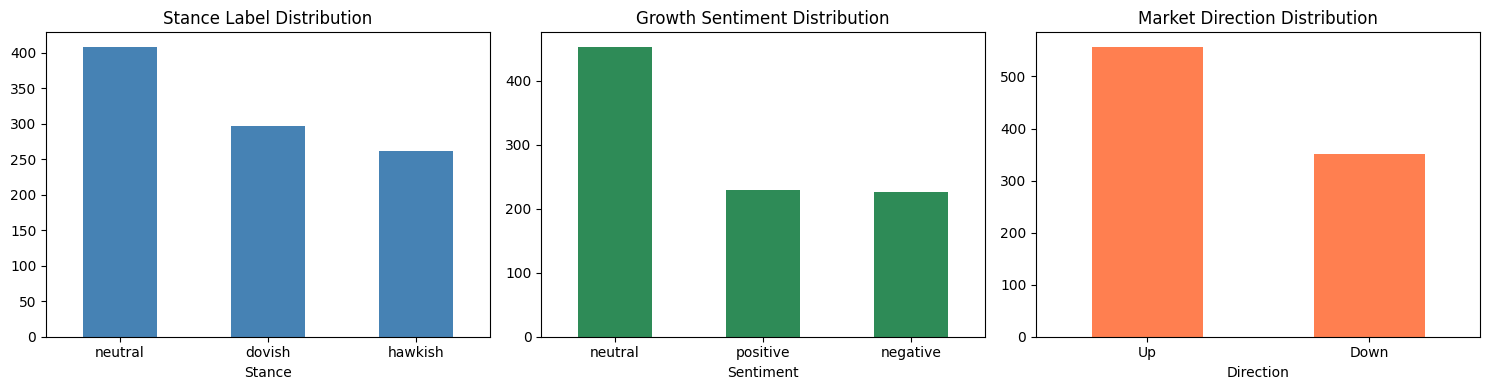

In [96]:
print("=" * 40)
print("PHASE 1: DATA DISTRIBUTION SUMMARY")
print("=" * 40)

print("\n1. Stance labels (hawkish/dovish dataset):")
print(fomc_labeled['stance_name'].value_counts(normalize=True).mul(100).round(1))

print("\n2. Growth sentiment (traditional FOMC dataset):")
print(master_df['growth_sentiment'].value_counts(normalize=True).mul(100).round(1))

print("\n3. Market target distribution (3-day SPY direction):")
counts = master_df['target_direction'].value_counts().rename({1: 'Up', 0: 'Down'})
print(counts)
print(counts / counts.sum() * 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fomc_labeled['stance_name'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Stance Label Distribution')
axes[0].set_xlabel('Stance')
axes[0].tick_params(axis='x', rotation=0)

master_df['growth_sentiment'].value_counts().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Growth Sentiment Distribution')
axes[1].set_xlabel('Sentiment')
axes[1].tick_params(axis='x', rotation=0)

master_df['target_direction'].value_counts().rename({1: 'Up', 0: 'Down'}).plot(
    kind='bar', ax=axes[2], color='coral')
axes[2].set_title('Market Direction Distribution')
axes[2].set_xlabel('Direction')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [97]:
# Save master datasets for downstream use
os.makedirs('./data/processed', exist_ok=True)
master_df.to_csv('./data/processed/fomc_market_master.csv', index=False)
fomc_labeled.to_csv('./data/processed/fomc_labeled_df.csv', index=False)
print("Saved data/processed/fomc_market_master.csv and fomc_labeled_df.csv")

Saved data/processed/fomc_market_master.csv and fomc_labeled_df.csv


## Phase 2 — Definitive Data Splits

All models use splits defined exactly once here and persisted to `data/processed/`. This eliminates the comparability problem caused by different cells using different `random_state` or stratification settings.

**RQ1 (stance classification):** Stratified 60 / 20 / 20 train / val / test split on `fomc_labeled`. Val is used only for early stopping and hyperparameter selection; test is used only to report final numbers.

**RQ2 (market prediction):** Chronological split on unique FOMC meeting dates (80 / 20). Random shuffling is explicitly prohibited to avoid look-ahead bias.

In [98]:
# ── RQ1: Stance classification splits ─────────────────────────────────────────
manual_df = fomc_labeled[['sentence', 'label']].copy()

# Hold out 20% as final test set
train_val_df, test_df = train_test_split(
    manual_df, test_size=0.20, random_state=RANDOM_SEED,
    stratify=manual_df['label']
)
# Split remaining 80% into 60% train / 20% val  (0.25 × 0.80 = 0.20 of total)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.25, random_state=RANDOM_SEED,
    stratify=train_val_df['label']
)

# Drop any within-split duplicates that survive stratified splitting
train_df = train_df.drop_duplicates('sentence', keep='first').reset_index(drop=True)
val_df   = val_df.drop_duplicates('sentence', keep='first').reset_index(drop=True)
test_df  = test_df.drop_duplicates('sentence', keep='first').reset_index(drop=True)

# Verify no cross-split contamination
_test_sents  = set(test_df['sentence'])
_train_leak  = train_df['sentence'].isin(_test_sents).sum()
_val_leak    = val_df['sentence'].isin(_test_sents).sum()
assert _train_leak == 0, f'{_train_leak} train sentences found in test set'
assert _val_leak   == 0, f'{_val_leak} val sentences found in test set'

print("RQ1 splits (deduplicated):")
print(f"  train: {len(train_df)} rows  val: {len(val_df)} rows  test: {len(test_df)} rows")
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    dist = df['label'].value_counts(normalize=True).sort_index()
    print(f"  {name} label dist: { {ID2LABEL[k]: round(v,3) for k,v in dist.items()} }")

# Save cleaned splits
train_df.to_csv('./data/processed/split_train.csv', index=False)
val_df.to_csv('./data/processed/split_val.csv', index=False)
test_df.to_csv('./data/processed/split_test.csv', index=False)

# ── RQ2: Market prediction temporal split ─────────────────────────────────────
# Split on unique meeting dates so no meeting straddles train/test
unique_dates = sorted(master_df['date'].unique())
cutoff_date  = unique_dates[int(len(unique_dates) * 0.80)]

train_market = master_df[master_df['date'] < cutoff_date].copy()
test_market  = master_df[master_df['date'] >= cutoff_date].copy()

print(f"\nRQ2 temporal splits (cutoff: {pd.Timestamp(cutoff_date).date()}):")
print(f"  train: {len(train_market)} rows  test: {len(test_market)} rows")
print(f"  train dates: {train_market['date'].min().date()} → {train_market['date'].max().date()}")
print(f"  test  dates: {test_market['date'].min().date()} → {test_market['date'].max().date()}")

RQ1 splits (deduplicated):
  train: 579 rows  val: 193 rows  test: 194 rows
  train label dist: {'dovish': 0.307, 'hawkish': 0.271, 'neutral': 0.421}
  val label dist: {'dovish': 0.306, 'hawkish': 0.269, 'neutral': 0.425}
  test label dist: {'dovish': 0.304, 'hawkish': 0.273, 'neutral': 0.423}

RQ2 temporal splits (cutoff: 2019-11-20):
  train: 684 rows  test: 224 rows
  train dates: 2006-01-03 → 2019-10-09
  test  dates: 2019-11-20 → 2023-02-22


## Phase 2 — Baseline Models

### RQ1 Baselines: TF-IDF + Logistic Regression and TF-IDF + SVM

Two bag-of-words baselines. Logistic Regression provides the standard linear baseline; SVM (linear kernel, class-balanced weights) serves as an additional comparison point. Both share the same TF-IDF vocabulary (max 1 000 features). Both models are logged to the `CS271-RQ1-Stance` MLflow experiment under run names `tfidf_lr` and `tfidf_svm`, recording hyperparameters (`model`, `vectorizer`, `max_features`, `C`, `kernel`, `class_weight`) and test metrics (`test_accuracy`, `test_macro_f1`).

In [99]:
mlflow.set_tracking_uri('sqlite:///./mlflow.db')
mlflow.set_experiment('CS271-RQ1-Stance')

tfidf         = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf.fit_transform(train_df['sentence'])
X_val_tfidf   = tfidf.transform(val_df['sentence'])
X_test_tfidf  = tfidf.transform(test_df['sentence'])

with mlflow.start_run(run_name='tfidf_lr'):
    mlflow.log_params({
        'model':        'LogisticRegression',
        'vectorizer':   'TfidfVectorizer',
        'max_features': 1000,
        'C':            1.0,
        'solver':       'lbfgs',
    })
    log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    log_reg.fit(X_train_tfidf, train_df['label'])
    y_pred_tfidf   = log_reg.predict(X_test_tfidf)
    tfidf_macro_f1 = f1_score(test_df['label'], y_pred_tfidf, average='macro')
    mlflow.log_metrics({
        'test_accuracy': accuracy_score(test_df['label'], y_pred_tfidf),
        'test_macro_f1': tfidf_macro_f1,
    })

print("TF-IDF + Logistic Regression — TEST SET")
print(f"Accuracy: {accuracy_score(test_df['label'], y_pred_tfidf):.4f}")
print(classification_report(
    test_df['label'], y_pred_tfidf,
    target_names=[ID2LABEL[i] for i in range(3)]
))

with mlflow.start_run(run_name='tfidf_svm'):
    mlflow.log_params({
        'model':        'SVC',
        'vectorizer':   'TfidfVectorizer',
        'max_features': 1000,
        'kernel':       'linear',
        'C':            1.0,
        'class_weight': 'balanced',
    })
    svm_clf = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=1000)),
        ('svm',   SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=RANDOM_SEED)),
    ])
    svm_clf.fit(train_df['sentence'], train_df['label'])
    y_pred_svm   = svm_clf.predict(test_df['sentence'])
    svm_macro_f1 = f1_score(test_df['label'], y_pred_svm, average='macro')
    mlflow.log_metrics({
        'test_accuracy': accuracy_score(test_df['label'], y_pred_svm),
        'test_macro_f1': svm_macro_f1,
    })

print("\nTF-IDF + SVM (linear, class_weight=balanced) — TEST SET")
print(f"Accuracy: {accuracy_score(test_df['label'], y_pred_svm):.4f}")
print(classification_report(
    test_df['label'], y_pred_svm,
    target_names=[ID2LABEL[i] for i in range(3)]
))


TF-IDF + Logistic Regression — TEST SET
Accuracy: 0.5567
              precision    recall  f1-score   support

      dovish       0.52      0.49      0.50        59
     hawkish       0.61      0.32      0.42        53
     neutral       0.56      0.76      0.65        82

    accuracy                           0.56       194
   macro avg       0.56      0.52      0.52       194
weighted avg       0.56      0.56      0.54       194


TF-IDF + SVM (linear, class_weight=balanced) — TEST SET
Accuracy: 0.5103
              precision    recall  f1-score   support

      dovish       0.49      0.58      0.53        59
     hawkish       0.48      0.40      0.43        53
     neutral       0.55      0.54      0.54        82

    accuracy                           0.51       194
   macro avg       0.50      0.50      0.50       194
weighted avg       0.51      0.51      0.51       194



### RQ2 Baselines: Majority Class and VADER

These two lightweight baselines establish the floor for market-direction prediction. The MLP-on-tabular-features baseline is omitted: with only ~130 FOMC events in the temporal train split, a three-feature MLP provides no reliable signal and inflates the baseline table without adding experimental value. Richer RQ2 models (event-aggregation + macro controls) are evaluated in Phase 4.

Both baselines are logged to the `CS271-RQ2-Market` MLflow experiment under run names `rq2_sentence_majority` and `rq2_sentence_vader`. Note these are sentence-level evaluations; the event-level majority class baseline is re-evaluated in Phase 4 under `rq2_majority_class`.

In [100]:
mlflow.set_tracking_uri('sqlite:///./mlflow.db')
mlflow.set_experiment('CS271-RQ2-Market')

# ── Majority class ────────────────────────────────────────────────────────────
with mlflow.start_run(run_name='rq2_sentence_majority'):
    mlflow.log_params({'model': 'MajorityClass', 'split': 'sentence-level'})
    majority_class = train_market['target_direction'].mode()[0]
    majority_preds = [majority_class] * len(test_market)
    majority_acc   = accuracy_score(test_market['target_direction'], majority_preds)
    mlflow.log_metrics({'test_accuracy': majority_acc})
print(f'Majority class baseline accuracy: {majority_acc:.4f}')

# ── VADER compound score ───────────────────────────────────────────────────────
with mlflow.start_run(run_name='rq2_sentence_vader'):
    mlflow.log_params({'model': 'VADER', 'threshold': 0.0, 'split': 'sentence-level'})
    vader_preds = (test_market['sentiment_vader_compound_score'] > 0).astype(int).values
    vader_acc   = accuracy_score(test_market['target_direction'], vader_preds)
    mlflow.log_metrics({'test_accuracy': vader_acc})
print(f'VADER sentiment baseline accuracy: {vader_acc:.4f}')


Majority class baseline accuracy: 0.7321
VADER sentiment baseline accuracy: 0.5179


## Phase 3 — BERT Model Evaluation (RQ1)

A unified pipeline executes all four BERT-family models in order: `bert-base-uncased`, `ProsusAI/finbert`, `ZiweiChen/FinBERT-FOMC`, and `distilbert-base-uncased`. Fine-tuned models share the same grid-search procedure; `FinBERT-FOMC` is evaluated zero-shot.

Set `RUN_BERT_TRAINING = True` to execute training/inference; the default loads pre-computed results from disk.

| Model | Evaluation | Result file | MLflow runs (CS271-RQ1-Stance) |
|---|---|---|---|
| `bert-base-uncased` | Fine-tuned grid search | `bert-uncased_results/bert_grid_results_v1.csv` | 24 runs — `bert-uncased_lr{lr}_bs{bs}_s{seed}` |
| `ProsusAI/finbert` | Fine-tuned grid search | `finbert_results/finbert_grid_results_v4.csv` | 24 runs — `finbert_lr{lr}_bs{bs}_s{seed}` |
| `ZiweiChen/FinBERT-FOMC` | Zero-shot | `finbert-fomc_results/finbert_fomc_test_preds_zs.npy` | 1 run — `finbert-fomc_zero_shot` |
| `distilbert-base-uncased` | Fine-tuned grid search | `distillbert_results/distilbert_grid_results_v1.csv` | 24 runs — `distilbert_lr{lr}_bs{bs}_s{seed}` |

**Grid (fine-tuned models):** 4 LRs × 2 batch sizes × 3 seeds = 24 runs per model. LRs: {3e-5, 2e-5, 1e-5, 1e-4} (standard BERT fine-tuning range); batch sizes: {16, 8}. Early stopping on validation loss (patience=2, max 5 epochs); best checkpoint per run selected by lowest val loss. Best (lr, bs) config selected by mean val macro-F1 across seeds; test metrics reported as mean ± std.

**Regularisation:** dropout=0.1 (BERT default; hidden + attention), weight decay=0.05, class-balanced cross-entropy loss.

**MLflow logging:** Fine-tuned models log one run per (lr, bs, seed) grid combination during training. The `FinBERT-FOMC` zero-shot model logs a single run with `test_macro_f1` and `test_accuracy` when `RUN_BERT_TRAINING = True`; loading pre-computed predictions does not create a new run.

In [101]:
mlflow.set_tracking_uri('sqlite:///./mlflow.db')
mlflow.set_experiment('CS271-RQ1-Stance')
print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('Active experiment:  ', mlflow.get_experiment_by_name('CS271-RQ1-Stance').name)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"\nDevice: {device}")
if device == "cpu":
    print("WARNING: No GPU detected. Grid search will be very slow on CPU (~hours).")

MAX_LENGTH     = 256
LEARNING_RATES = [3e-5, 2e-5, 1e-5, 1e-4]
BATCH_SIZES    = [16, 8]
SEEDS          = [5768, 78516, 944601]

# Set True to re-run training/inference; False loads pre-computed results from disk.
RUN_BERT_TRAINING = False

BERT_MODELS = [
    {
        'id':   'bert-base-uncased',
        'slug': 'bert-uncased',
        'type': 'finetune',
        'checkpoint': './bert-uncased_results/bert_grid_results_v1.csv',
        'preds':      './bert-uncased_results/bert_best_test_preds.npy',
    },
    {
        'id':   'ProsusAI/finbert',
        'slug': 'finbert',
        'type': 'finetune',
        'checkpoint':              './finbert_results/finbert_grid_results_v4.csv',
        'preds':                   './finbert_results/finbert_best_test_preds_v4.npy',
        'ignore_mismatched_sizes': True,
    },
    {
        'id':   'ZiweiChen/FinBERT-FOMC',
        'slug': 'finbert-fomc',
        'type': 'zero-shot',
        'preds': './finbert-fomc_results/finbert_fomc_test_preds_zs.npy',
    },
    {
        'id':   'distilbert-base-uncased',
        'slug': 'distilbert',
        'type': 'finetune',
        'checkpoint': './distillbert_results/distilbert_grid_results_v1.csv',
        'preds':      './distillbert_results/distilbert_best_test_preds.npy',
    },
]

total_grid_runs = len(LEARNING_RATES) * len(BATCH_SIZES) * len(SEEDS)
print(f"\nGrid: {len(LEARNING_RATES)} LRs × {len(BATCH_SIZES)} batch sizes × {len(SEEDS)} seeds = {total_grid_runs} runs per fine-tuned model")
print(f"Models: {[m['slug'] for m in BERT_MODELS]}")

MLflow tracking URI: sqlite:///./mlflow.db
Active experiment:   CS271-RQ1-Stance

Device: mps

Grid: 4 LRs × 2 batch sizes × 3 seeds = 24 runs per fine-tuned model
Models: ['bert-uncased', 'finbert', 'finbert-fomc', 'distilbert']


In [102]:
def _make_bert_dataset(df, tokenizer):
    """Tokenize df and return a HuggingFace Dataset ready for Trainer."""
    ds = Dataset.from_pandas(df.reset_index(drop=True))
    ds = ds.map(
        lambda ex: tokenizer(ex['sentence'], truncation=True, max_length=MAX_LENGTH),
        batched=True
    )
    keep = ['input_ids', 'attention_mask', 'label']
    ds = ds.remove_columns([c for c in ds.column_names if c not in keep])
    ds.set_format('torch')
    return ds

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy':    accuracy_score(labels, preds),
        'macro_f1':    f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
    }



from torch.nn import CrossEntropyLoss
from sklearn.utils.class_weight import compute_class_weight as _cw

class WeightedTrainer(Trainer):
    """Trainer subclass that applies class-balanced cross-entropy loss."""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        w = self._class_weights.to(outputs.logits.device) if self._class_weights is not None else None
        loss = CrossEntropyLoss(weight=w)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

print("Helper functions defined: _make_bert_dataset, compute_metrics, WeightedTrainer")

Helper functions defined: _make_bert_dataset, compute_metrics, WeightedTrainer


In [103]:
def run_bert_finetune(model_cfg, train_df, val_df, test_df):
    """Grid search fine-tuning for a BERT-family model. Checkpoint per run; safely resumable."""
    import shutil
    slug       = model_cfg['slug']
    model_id   = model_cfg['id']
    ckpt_path  = model_cfg['checkpoint']
    preds_path = model_cfg['preds']
    runs_dir   = f'./{slug}_runs'
    extra_kw   = {'ignore_mismatched_sizes': True} if model_cfg.get('ignore_mismatched_sizes') else {}

    tokenizer   = AutoTokenizer.from_pretrained(model_id)
    train_ds    = _make_bert_dataset(train_df, tokenizer)
    val_ds      = _make_bert_dataset(val_df,   tokenizer)
    test_ds     = _make_bert_dataset(test_df,  tokenizer)
    test_labels = np.array(test_df['label'])

    if os.path.exists(ckpt_path):
        grid_df   = pd.read_csv(ckpt_path)
        completed = {(row.lr, int(row.bs), int(row.seed)) for row in grid_df.itertuples()}
        print(f'[{slug}] Resuming: {len(completed)} runs already complete.')
        cleaned = 0
        for lr_c, bs_c, seed_c in completed:
            d = f'{runs_dir}/lr{lr_c}_bs{bs_c}_s{seed_c}'
            if os.path.exists(d):
                shutil.rmtree(d); cleaned += 1
        if cleaned:
            print(f'[{slug}] Freed {cleaned} stale run directories.')
    else:
        grid_df   = pd.DataFrame()
        completed = set()
        print(f'[{slug}] No checkpoint found — starting fresh.')

    total_runs = len(LEARNING_RATES) * len(BATCH_SIZES) * len(SEEDS)
    remaining  = [
        (lr, bs, seed)
        for lr, bs, seed in itertools.product(LEARNING_RATES, BATCH_SIZES, SEEDS)
        if (lr, bs, seed) not in completed
    ]
    print(f'[{slug}] Total: {total_runs}  Done: {len(completed)}  Remaining: {len(remaining)}')

    best_val = grid_df['val_macro_f1'].max() if not grid_df.empty else -1.0
    done     = len(completed)

    for lr, bs, seed in remaining:
        # Flush device memory before allocating a new model for this run.
        gc.collect()
        if device == 'mps':   torch.mps.empty_cache()
        elif device == 'cuda': torch.cuda.empty_cache()

        done += 1
        print(f'\n[{slug}] [{done}/{total_runs}]  lr={lr:.0e}  bs={bs}  seed={seed}')

        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

        with mlflow.start_run(run_name=f'{slug}_lr{lr:.0e}_bs{bs}_s{seed}'):
            mlflow.log_params({
                'model': model_id, 'lr': lr, 'bs': bs, 'seed': seed,
                'max_length': MAX_LENGTH, 'weight_decay': 0.05,
                'warmup_ratio': 0.1, 'patience': 2, 'max_epochs': 5,
                'dropout': 0.1, 'metric_for_best': 'eval_loss',
            })

            _cfg = AutoConfig.from_pretrained(
                model_id, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID,
                hidden_dropout_prob=0.1, attention_probs_dropout_prob=0.1,
            )
            model = AutoModelForSequenceClassification.from_pretrained(
                model_id, config=_cfg, **extra_kw
            )
            args = TrainingArguments(
                output_dir=f'{runs_dir}/lr{lr}_bs{bs}_s{seed}',
                eval_strategy='epoch', save_strategy='epoch', logging_strategy='epoch',
                learning_rate=lr, per_device_train_batch_size=bs,
                per_device_eval_batch_size=32, num_train_epochs=5,
                weight_decay=0.05, lr_scheduler_type='linear', warmup_ratio=0.1,
                load_best_model_at_end=True, metric_for_best_model='eval_loss',
                greater_is_better=False, save_total_limit=1, seed=seed,
                dataloader_pin_memory=False, report_to='none'
            )
            _weights = torch.tensor(
                _cw('balanced', classes=np.array([0,1,2]), y=train_df['label'].values),
                dtype=torch.float
            )
            trainer = WeightedTrainer(
                model=model, args=args,
                train_dataset=train_ds, eval_dataset=val_ds,
                data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
                compute_metrics=compute_metrics,
                class_weights=_weights,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
            )
            trainer.train()

            val_out  = trainer.evaluate(val_ds)
            val_f1   = val_out['eval_macro_f1']
            val_wf1  = val_out['eval_weighted_f1']
            val_loss = val_out['eval_loss']

            pred_out = trainer.predict(test_ds)
            preds    = np.argmax(pred_out.predictions, axis=1)
            test_mf1 = f1_score(test_labels, preds, average='macro')
            test_wf1 = f1_score(test_labels, preds, average='weighted')
            test_acc = accuracy_score(test_labels, preds)

            mlflow.log_metrics({
                'val_loss':         val_loss,  'val_macro_f1':     val_f1,
                'val_weighted_f1':  val_wf1,   'test_macro_f1':    test_mf1,
                'test_weighted_f1': test_wf1,  'test_accuracy':    test_acc,
            })

            if val_f1 > best_val:
                best_val = val_f1
                np.save(preds_path, preds)
                print(f'  ** New best val_macro_f1={val_f1:.4f} — predictions saved **')

            row = {
                'lr': lr, 'bs': bs, 'seed': seed,
                'val_loss':         round(val_loss,  5),
                'val_macro_f1':     round(val_f1,    5),
                'val_weighted_f1':  round(val_wf1,   5),
                'test_macro_f1':    round(test_mf1,  5),
                'test_weighted_f1': round(test_wf1,  5),
                'test_accuracy':    round(test_acc,  5),
            }
            grid_df = pd.concat([grid_df, pd.DataFrame([row])], ignore_index=True)
            grid_df.to_csv(ckpt_path, index=False)
            print(f'  val_mf1={val_f1:.4f}  test_mf1={test_mf1:.4f}  acc={test_acc:.4f}')
            print(f'  [{done}/{total_runs}] checkpoint saved.')

        del model, trainer
        gc.collect()
        if device == 'mps':   torch.mps.empty_cache()
        elif device == 'cuda': torch.cuda.empty_cache()

        run_out_dir = f'{runs_dir}/lr{lr}_bs{bs}_s{seed}'
        if os.path.exists(run_out_dir):
            shutil.rmtree(run_out_dir)

    print(f'\n[{slug}] Training complete. {len(grid_df)} runs saved to {ckpt_path}.')
    return grid_df

print("run_bert_finetune defined.")

run_bert_finetune defined.


In [12]:
def run_bert_zero_shot(model_cfg, test_sentences, test_labels):
    """Zero-shot evaluation for a task-specific BERT model. Saves predictions to disk."""
    slug       = model_cfg['slug']
    model_id   = model_cfg['id']
    preds_path = model_cfg['preds']

    config = AutoConfig.from_pretrained(model_id)
    print(f'[{slug}] id2label: {config.id2label}')

    # ZiweiChen/FinBERT-FOMC uses Positive/Negative/Neutral; map to hawkish/dovish/neutral.
    _sem_map = {
        'positive': LABEL2ID['hawkish'],
        'negative': LABEL2ID['dovish'],
        'neutral':  LABEL2ID['neutral'],
        'hawkish':  LABEL2ID['hawkish'],
        'dovish':   LABEL2ID['dovish'],
    }
    label_map = {
        lbl: _sem_map.get(lbl.strip().lower(), LABEL2ID['neutral'])
        for lbl in config.id2label.values()
    }
    print(f'[{slug}] Label map: {label_map}')

    pipe  = hf_pipeline(
        'text-classification', model=model_id, tokenizer=model_id,
        truncation=True, max_length=MAX_LENGTH,
        device=0 if device == 'cuda' else -1
    )
    preds = np.array([
        label_map.get(o['label'], LABEL2ID['neutral'])
        for o in pipe(list(test_sentences), batch_size=32)
    ])
    test_labels = np.asarray(test_labels)

    print(f'\n[{slug}] Zero-Shot — TEST SET')
    print(f'Accuracy: {accuracy_score(test_labels, preds):.4f}')
    print(classification_report(
        test_labels, preds,
        labels=[0, 1, 2],
        target_names=[ID2LABEL[i] for i in range(3)],
        zero_division=0
    ))

    np.save(preds_path, preds)
    pd.DataFrame(
        classification_report(
            test_labels, preds, labels=[0, 1, 2],
            target_names=[ID2LABEL[i] for i in range(3)],
            output_dict=True, zero_division=0
        )
    ).T.to_csv(preds_path.replace('.npy', '_report.csv'))
    print(f'[{slug}] Predictions saved to {preds_path}')

    return preds

print("run_bert_zero_shot defined.")

run_bert_zero_shot defined.


In [13]:
# Executes each BERT model in order: bert-uncased → finbert → finbert-fomc → distilbert.
# Set RUN_BERT_TRAINING = True (config cell above) to re-run; default loads pre-computed results.
# Fine-tuned models log every grid run inside run_bert_finetune (CS271-RQ1-Stance experiment).
# Zero-shot models log a single run here when inference is executed.

bert_results = {}   # slug -> grid_df (finetune) or preds array (zero-shot)

for model_cfg in BERT_MODELS:
    slug = model_cfg['slug']
    print(f'\n{"="*60}')
    print(f'Model: {model_cfg["id"]}  ({model_cfg["type"]})')
    print('='*60)

    if model_cfg['type'] == 'finetune':
        ckpt_path  = model_cfg['checkpoint']
        preds_path = model_cfg['preds']

        if RUN_BERT_TRAINING or not os.path.exists(ckpt_path):
            run_bert_finetune(model_cfg, train_df, val_df, test_df)
        else:
            print(f'[{slug}] RUN_BERT_TRAINING=False — loading pre-computed results.')

        if os.path.exists(ckpt_path):
            bert_results[slug] = pd.read_csv(ckpt_path)
            print(f'[{slug}] Loaded {len(bert_results[slug])} grid runs from {ckpt_path}')

    else:  # zero-shot
        preds_path = model_cfg['preds']

        if RUN_BERT_TRAINING or not os.path.exists(preds_path):
            with mlflow.start_run(run_name=f'{slug}_zero_shot'):
                mlflow.log_params({
                    'model': model_cfg['id'],
                    'type':  'zero-shot',
                })
                preds = run_bert_zero_shot(
                    model_cfg, test_df['sentence'].tolist(), test_df['label'].tolist()
                )
                bert_results[slug] = preds
                mlflow.log_metrics({
                    'test_macro_f1': f1_score(test_df['label'].values, preds,
                                              average='macro', zero_division=0),
                    'test_accuracy': accuracy_score(test_df['label'].values, preds),
                })
        else:
            print(f'[{slug}] RUN_BERT_TRAINING=False — loading pre-computed predictions.')
            bert_results[slug] = np.load(preds_path)
            print(f'[{slug}] Loaded {len(bert_results[slug])} predictions from {preds_path}')

# Expose legacy variable name used by downstream summary cells
test_preds_fomc_zs = bert_results.get('finbert-fomc', np.array([]))

print(f'\nAll BERT models complete. Results keys: {list(bert_results.keys())}')



Model: bert-base-uncased  (finetune)


Map: 100%|██████████| 194/194 [00:00<00:00, 24405.97 examples/s]


[bert-uncased] No checkpoint found — starting fresh.
[bert-uncased] Total: 24  Done: 0  Remaining: 24

[bert-uncased] [1/24]  lr=3e-05  bs=16  seed=5768


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6761.33it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.096555,1.082166,0.419689,0.314550,0.351853
2,1.029516,0.999509,0.481865,0.438712,0.453966
3,0.777808,0.934466,0.528497,0.526901,0.532948
4,0.547244,0.944976,0.554404,0.557618,0.560488
5,0.378613,0.949561,0.554404,0.545742,0.555481


...

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7850.53it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.108513,1.084329,0.341969,0.295614,0.261963
2,0.932331,0.984455,0.554404,0.540039,0.552932
3,0.587524,1.025536,0.601036,0.603571,0.600666
4,0.214150,1.574423,0.606218,0.605313,0.606670


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.29it/s]


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.214150,0.984455,4,0.554404,0.540039,0.552932


  val_mf1=0.5400  test_mf1=0.5256  acc=0.5258
  [24/24] checkpoint saved.

[distilbert] Training complete. 24 runs saved to ./distilbert_grid_results_v1.csv.
[distilbert] Loaded 24 grid runs from ./distilbert_grid_results_v1.csv

All BERT models complete. Results keys: ['bert-uncased', 'finbert', 'finbert-fomc', 'distilbert']


### BERT Models — Results

One section per model: grid-search summary, per-class report, confusion matrix, and validation heatmap for fine-tuned models; per-class report and confusion matrix for zero-shot models.


  bert-uncased  (bert-base-uncased)  —  FINETUNE

      LR    BS        Val Loss       Val MacF1        Val WtF1      Test MacF1       Test WtF1
----------------------------------------------------------------------------------------------------
3e-05     8  0.9499+/-0.0874  0.5634+/-0.0276  0.5682+/-0.0217  0.5675+/-0.0556  0.5673+/-0.0489
3e-05    16  0.9781+/-0.0388  0.5190+/-0.0069  0.5263+/-0.0061  0.5380+/-0.0196  0.5372+/-0.0149
2e-05    16  1.0037+/-0.0407  0.4837+/-0.0247  0.4871+/-0.0298  0.5302+/-0.0224  0.5312+/-0.0265
2e-05     8  0.9688+/-0.0222  0.4745+/-0.0312  0.4719+/-0.0420  0.5473+/-0.0247  0.5469+/-0.0246
1e-05     8  1.0154+/-0.0287  0.4621+/-0.0318  0.4673+/-0.0395  0.5260+/-0.0287  0.5255+/-0.0311
1e-04     8  1.0479+/-0.0138  0.4507+/-0.0957  0.4622+/-0.0878  0.4763+/-0.0691  0.4880+/-0.0598
1e-04    16  1.0190+/-0.0744  0.4419+/-0.1058  0.4449+/-0.0946  0.4760+/-0.1036  0.4845+/-0.0916
1e-05    16  1.0368+/-0.0286  0.4283+/-0.0495  0.4285+/-0.0531  0.4684+/-0

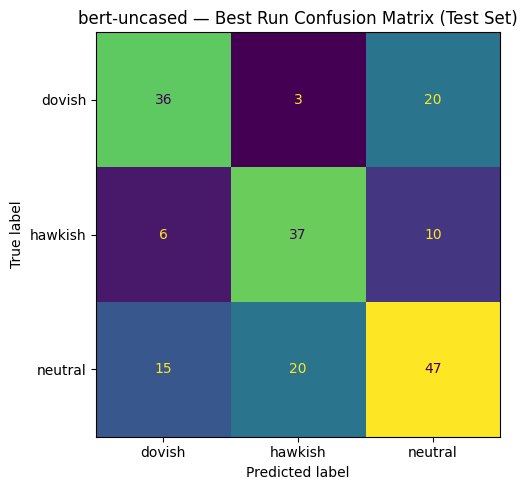

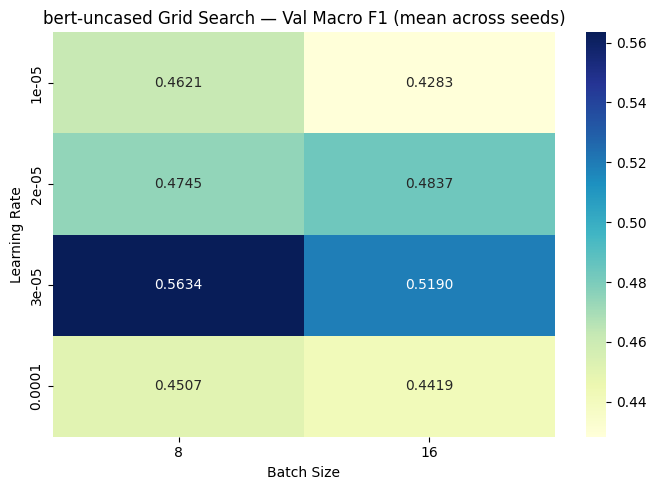


  finbert  (ProsusAI/finbert)  —  FINETUNE

      LR    BS        Val Loss       Val MacF1        Val WtF1      Test MacF1       Test WtF1
----------------------------------------------------------------------------------------------------
3e-05    16  1.0109+/-0.0115  0.5088+/-0.0233  0.5219+/-0.0265  0.5068+/-0.0139  0.5218+/-0.0122
2e-05    16  1.0186+/-0.0232  0.5067+/-0.0327  0.5156+/-0.0368  0.5268+/-0.0308  0.5399+/-0.0310
1e-05    16  1.0264+/-0.0154  0.4988+/-0.0144  0.5114+/-0.0102  0.4942+/-0.0277  0.5126+/-0.0258
1e-05     8  1.0224+/-0.0171  0.4955+/-0.0469  0.5109+/-0.0431  0.5004+/-0.0293  0.5186+/-0.0307
2e-05     8  1.0276+/-0.0182  0.4626+/-0.0534  0.4721+/-0.0533  0.4884+/-0.0536  0.5022+/-0.0465
1e-04     8  1.0289+/-0.0364  0.4505+/-0.0639  0.4631+/-0.0642  0.4537+/-0.0574  0.4690+/-0.0544
3e-05     8  1.0472+/-0.0278  0.3947+/-0.1367  0.3995+/-0.1447  0.4039+/-0.0904  0.4129+/-0.0944
1e-04    16  1.0512+/-0.0623  0.3947+/-0.1260  0.4105+/-0.1304  0.4000+/-0.1117 

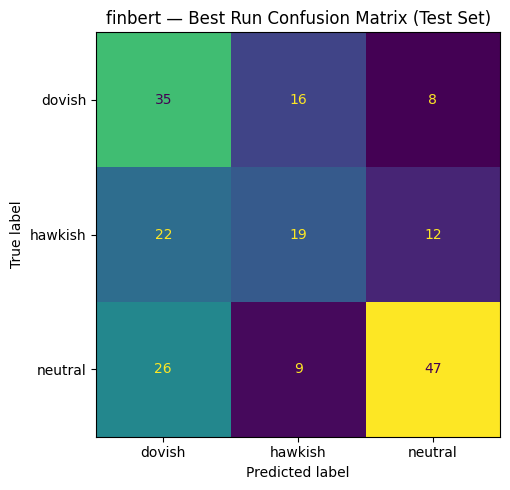

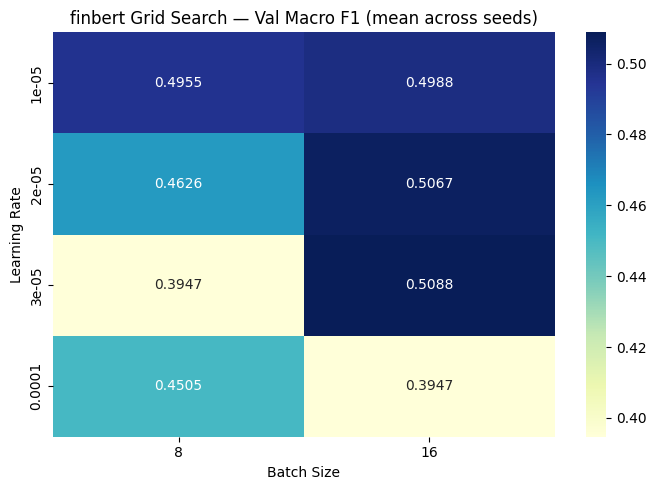


  finbert-fomc  (ZiweiChen/FinBERT-FOMC)  —  ZERO-SHOT

Accuracy: 0.4588
              precision    recall  f1-score   support

      dovish       0.45      0.63      0.52        59
     hawkish       0.30      0.34      0.32        53
     neutral       0.67      0.41      0.51        82

    accuracy                           0.46       194
   macro avg       0.47      0.46      0.45       194
weighted avg       0.50      0.46      0.46       194



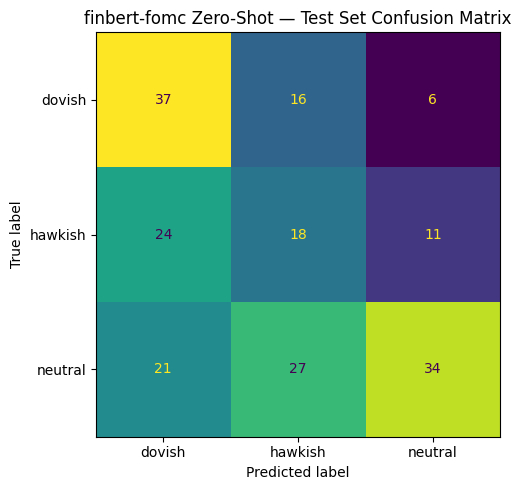


  distilbert  (distilbert-base-uncased)  —  FINETUNE

      LR    BS        Val Loss       Val MacF1        Val WtF1      Test MacF1       Test WtF1
----------------------------------------------------------------------------------------------------
1e-04     8  0.9882+/-0.0586  0.5790+/-0.0390  0.5880+/-0.0378  0.5581+/-0.0432  0.5610+/-0.0407
3e-05     8  0.9413+/-0.0400  0.5609+/-0.0169  0.5655+/-0.0165  0.5953+/-0.0290  0.5966+/-0.0241
2e-05     8  0.9452+/-0.0494  0.5544+/-0.0340  0.5622+/-0.0340  0.5225+/-0.0107  0.5271+/-0.0119
3e-05    16  0.9654+/-0.0339  0.5375+/-0.0188  0.5441+/-0.0156  0.5366+/-0.0399  0.5384+/-0.0384
2e-05    16  0.9714+/-0.0307  0.5234+/-0.0169  0.5309+/-0.0122  0.5151+/-0.0517  0.5173+/-0.0485
1e-05     8  1.0009+/-0.0208  0.5048+/-0.0157  0.5094+/-0.0127  0.4681+/-0.0314  0.4708+/-0.0306
1e-05    16  1.0539+/-0.0062  0.4601+/-0.0317  0.4600+/-0.0244  0.4620+/-0.0360  0.4631+/-0.0329
1e-04    16  1.0221+/-0.0417  0.4382+/-0.0711  0.4528+/-0.0580  0.4540

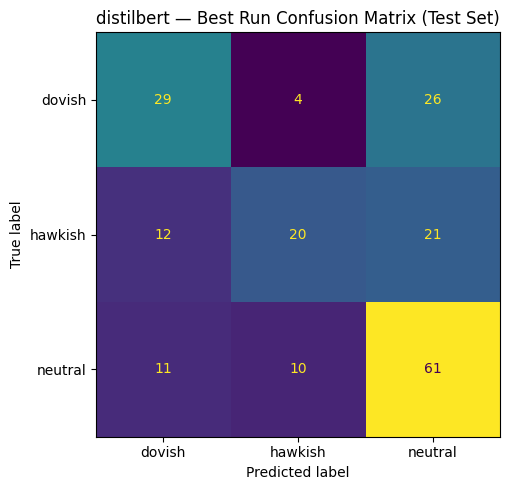

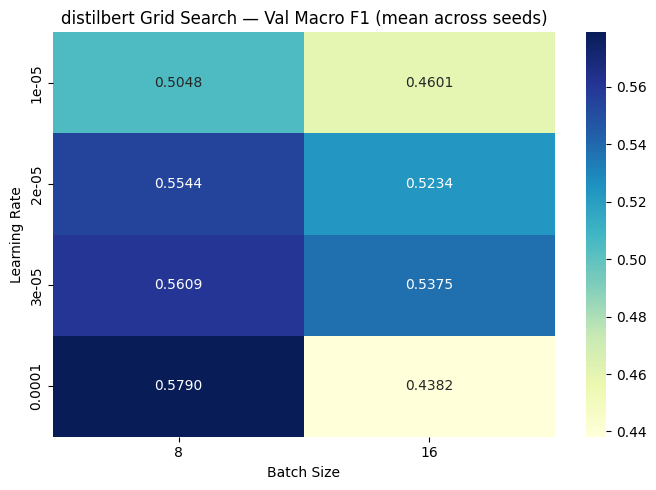

In [104]:
# ── BERT Models — Results ─────────────────────────────────────────────────────
# Loops over BERT_MODELS config. Fine-tuned models: grid-search summary table,
# best-config printout, per-class report, confusion matrix, val macro-F1 heatmap.
# Zero-shot models: accuracy, per-class report, confusion matrix.

# Self-recovery guard: load any missing bert_results entries from disk
if 'bert_results' not in globals():
    bert_results = {}
for _cfg in BERT_MODELS:
    _sl = _cfg['slug']
    if _sl not in bert_results or (
            _cfg['type'] == 'finetune' and not isinstance(bert_results.get(_sl), pd.DataFrame)):
        if _cfg['type'] == 'finetune' and os.path.exists(_cfg['checkpoint']):
            bert_results[_sl] = pd.read_csv(_cfg['checkpoint'])
        elif _cfg['type'] != 'finetune' and os.path.exists(_cfg.get('preds', '')):
            bert_results[_sl] = np.load(_cfg['preds'])

for model_cfg in BERT_MODELS:
    slug     = model_cfg['slug']
    model_id = model_cfg['id']

    print(f'\n{"="*70}')
    print(f'  {slug}  ({model_id})  —  {model_cfg["type"].upper()}')
    print(f'{"="*70}\n')

    if model_cfg['type'] == 'finetune':
        ckpt_path  = model_cfg['checkpoint']
        preds_path = model_cfg['preds']

        if slug in bert_results and isinstance(bert_results.get(slug), pd.DataFrame):
            grid_df_m = bert_results[slug]
        elif os.path.exists(ckpt_path):
            grid_df_m = pd.read_csv(ckpt_path)
        else:
            print(f'  No results found — run execution cell with RUN_BERT_TRAINING=True.')
            continue

        summary = (
            grid_df_m
            .groupby(['lr', 'bs'])
            .agg(
                val_loss_mean      =('val_loss',         'mean'),
                val_loss_std       =('val_loss',         'std'),
                val_macro_f1_mean  =('val_macro_f1',     'mean'),
                val_macro_f1_std   =('val_macro_f1',     'std'),
                val_wf1_mean       =('val_weighted_f1',  'mean'),
                val_wf1_std        =('val_weighted_f1',  'std'),
                test_macro_f1_mean =('test_macro_f1',    'mean'),
                test_macro_f1_std  =('test_macro_f1',    'std'),
                test_wf1_mean      =('test_weighted_f1', 'mean'),
                test_wf1_std       =('test_weighted_f1', 'std'),
                test_acc_mean      =('test_accuracy',    'mean'),
                test_acc_std       =('test_accuracy',    'std'),
            )
            .reset_index()
            .sort_values('val_macro_f1_mean', ascending=False)
            .reset_index(drop=True)
        )

        print(f"{'LR':>8}  {'BS':>4}  {'Val Loss':>14}  {'Val MacF1':>14}  {'Val WtF1':>14}  {'Test MacF1':>14}  {'Test WtF1':>14}")
        print('-' * 100)
        for _, row in summary.iterrows():
            print(f"{row['lr']:.0e}  {int(row['bs']):>4}  "
                  f"{row['val_loss_mean']:.4f}+/-{row['val_loss_std']:.4f}  "
                  f"{row['val_macro_f1_mean']:.4f}+/-{row['val_macro_f1_std']:.4f}  "
                  f"{row['val_wf1_mean']:.4f}+/-{row['val_wf1_std']:.4f}  "
                  f"{row['test_macro_f1_mean']:.4f}+/-{row['test_macro_f1_std']:.4f}  "
                  f"{row['test_wf1_mean']:.4f}+/-{row['test_wf1_std']:.4f}")

        best = summary.iloc[0]
        print(f"\nBest config:  lr={best['lr']:.0e}  bs={int(best['bs'])}")
        print(f"  Val  loss:     {best['val_loss_mean']:.4f} +/- {best['val_loss_std']:.4f}")
        print(f"  Val  macro F1: {best['val_macro_f1_mean']:.4f} +/- {best['val_macro_f1_std']:.4f}")
        print(f"  Val  wtd   F1: {best['val_wf1_mean']:.4f} +/- {best['val_wf1_std']:.4f}")
        print(f"  Test macro F1: {best['test_macro_f1_mean']:.4f} +/- {best['test_macro_f1_std']:.4f}")
        print(f"  Test wtd   F1: {best['test_wf1_mean']:.4f} +/- {best['test_wf1_std']:.4f}")
        print(f"  Test accuracy: {best['test_acc_mean']:.4f} +/- {best['test_acc_std']:.4f}")

        summary_path = ckpt_path.replace('.csv', '_summary.csv')
        summary.to_csv(summary_path, index=False)
        print(f"\nSaved {summary_path}")

        if not os.path.exists(preds_path):
            print(f'  Predictions not found at {preds_path} — skipping report/plots.')
            continue

        preds_m  = np.load(preds_path)
        labels_m = np.array(test_df['label'])

        print(f'\nPer-Class Classification Report (best run):')
        print(classification_report(labels_m, preds_m,
                                    labels=[0,1,2], target_names=[ID2LABEL[i] for i in range(3)],
                                    zero_division=0))

        rpt_path = ckpt_path.replace('grid_results', 'test_report')
        pd.DataFrame(
            classification_report(labels_m, preds_m, labels=[0,1,2],
                                  target_names=[ID2LABEL[i] for i in range(3)],
                                  output_dict=True, zero_division=0)
        ).T.to_csv(rpt_path)
        print(f'Saved {rpt_path}')

        cm_m = confusion_matrix(labels_m, preds_m, labels=[0,1,2])
        disp = ConfusionMatrixDisplay(cm_m, display_labels=[ID2LABEL[i] for i in range(3)])
        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, values_format='d', colorbar=False)
        ax.set_title(f'{slug} — Best Run Confusion Matrix (Test Set)')
        plt.tight_layout(); plt.show()

        pivot = summary.pivot(index='lr', columns='bs', values='val_macro_f1_mean')
        fig, ax = plt.subplots(figsize=(7, 5))
        sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax)
        ax.set_title(f'{slug} Grid Search — Val Macro F1 (mean across seeds)')
        ax.set_xlabel('Batch Size'); ax.set_ylabel('Learning Rate')
        plt.tight_layout(); plt.show()

    else:  # zero-shot
        _preds = bert_results.get(slug, np.array([]))
        if len(_preds) == 0:
            print(f'  No predictions found — run execution cell with RUN_BERT_TRAINING=True.')
            continue

        labels_zs = np.array(test_df['label'])
        print(f'Accuracy: {accuracy_score(labels_zs, _preds):.4f}')
        print(classification_report(labels_zs, _preds,
                                    labels=[0,1,2], target_names=[ID2LABEL[i] for i in range(3)],
                                    zero_division=0))

        cm_zs = confusion_matrix(labels_zs, _preds, labels=[0,1,2])
        disp  = ConfusionMatrixDisplay(cm_zs, display_labels=[ID2LABEL[i] for i in range(3)])
        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, values_format='d', colorbar=False)
        ax.set_title(f'{slug} Zero-Shot — Test Set Confusion Matrix')
        plt.tight_layout(); plt.show()


# ── Legacy variable aliases used by downstream cells ─────────────────────────
_fb_cfg   = next((m for m in BERT_MODELS if m['slug'] == 'finbert'),      None)
_bu_cfg   = next((m for m in BERT_MODELS if m['slug'] == 'bert-uncased'), None)
_fomc_cfg = next((m for m in BERT_MODELS if m['slug'] == 'finbert-fomc'), None)

fb_preds = (np.load(_fb_cfg['preds'])
            if _fb_cfg and os.path.exists(_fb_cfg['preds']) else np.array([]))
fb_true  = np.array(test_df['label'])

test_preds_fomc_zs = bert_results.get('finbert-fomc', np.array([]))
test_labels_fomc   = test_df['label'].tolist()
fomc_zs_macro_f1   = (f1_score(test_labels_fomc, test_preds_fomc_zs, average='macro', zero_division=0)
                      if len(test_preds_fomc_zs) > 0 else float('nan'))
finbert_macro_f1   = (f1_score(fb_true, fb_preds, average='macro', zero_division=0)
                      if len(fb_preds) > 0 else float('nan'))

if (_bu_cfg and _bu_cfg['slug'] in bert_results
        and isinstance(bert_results[_bu_cfg['slug']], pd.DataFrame)):
    _bu_best = (bert_results[_bu_cfg['slug']]
                .groupby(['lr', 'bs'])
                .agg(val_mf1_mean=('val_macro_f1', 'mean'),
                     test_mf1_mean=('test_macro_f1', 'mean'),
                     test_acc_mean=('test_accuracy', 'mean'))
                .reset_index().sort_values('val_mf1_mean', ascending=False).iloc[0])
    bert_macro_f1 = _bu_best['test_mf1_mean']
    bert_acc      = _bu_best['test_acc_mean']
else:
    bert_macro_f1 = bert_acc = float('nan')


## Phase 3 — LLM Stance Labeling (RQ1 + RQ2 feature source)

Two labeling backends are supported: **Groq** (fast inference, strict rate limits) and **AWS Bedrock** (pay-per-token, more generous limits, access to frontier models). Both backends process the same two corpora — the RQ1 corpus (966 unique sentences from `fomc_labeled`) and the RQ2 corpus (908 unique sentences from `fomc_dated`) — using the identical 7-shot prompt and batch-10 loop, making all results directly comparable across providers and models.

Labels are checkpointed per model under `llm_outputs/{slug}/` so runs are safely resumable across sessions. Pre-computed outputs are loaded automatically when the corresponding run flag is `False` — previous labeling results are always picked up from disk regardless of which backend produced them.

| Backend | Run flag | Model list | Requires |
|---------|----------|------------|----------|
| Groq | `RUN_LLM_LABELING = True` | `GROQ_MODELS` | `GROQ_API_KEY` env var |
| AWS Bedrock | `RUN_BEDROCK_LABELING = True` | `BEDROCK_MODELS` | AWS credentials + Bedrock model access enabled in console |

To add a model to either backend, append an entry to the relevant list and re-run — rows already checkpointed are skipped automatically.

In [30]:
from groq import Groq

# ── Configuration ─────────────────────────────────────────────────────────────
GROQ_API_KEY     = os.environ.get('GROQ_API_KEY', '')
RUN_LLM_LABELING = False  # Set True to execute Groq API calls

GROQ_MODELS = [
    # {'id': 'llama-3.3-70b-versatile', 'slug': 'llama33-70b'},
    # {'id': 'openai/gpt-oss-120b',     'slug': 'gpt-oss-120b', 'max_tokens': 2048},
    # {'id': 'llama-3.1-8b-instant',   'slug': 'llama31-8b'},
     {'id': 'openai/gpt-oss-20b',     'slug': 'gpt-oss-20b',  'max_tokens': 2048},
]

LLM_BATCH_SIZE             = 10
LLM_SLEEP_BETWEEN_BATCHES  = 20   # seconds; increase if hitting TPM limits
LLM_MAX_TOKENS             = 300
LLM_LABEL_LIMIT            = None   # Max sentences per corpus; set None for full run

# 2 dovish / 2 hawkish / 3 neutral — mirrors ~30/27/43% gold distribution.
# All sentences verified NOT present in split_test.csv.
# Replacements from prior version:
#   - "Both of these views..." removed: was in test set with MISMATCHED label (example=neutral, gold=dovish)
#   - "Available information...foreign countries..." removed: was in test set (matched label, but improper exposure)
FEW_SHOT_EXAMPLES = [
    # Dovish: describes or signals below-target inflation, labor weakness, or need for accommodation
    ("Housing activity was generally holding up well across the country as the effects of appreciably reduced mortgage interest rates apparently compensated for the negative effects of declining financial wealth on the demand for housing.", 0),
    ("Members noted that inflation had been running persistently below the Committee's 2 percent longer-run objective, and that maintaining the current accommodative stance remained appropriate to support a return to target.", 0),
    # Hawkish: describes or signals above-target inflation, rising expectations, overheating, or need to tighten
    ("A discernable upcreep was apparent in survey measures of short- and, to a limited extent, long-term inflation expectations over recent months.", 1),
    ("Indeed, in the interest of fostering a continuation of sustainable growth of the economy, it would be desirable to tighten before any sign of actual higher inflation were to become evident.", 1),
    # Neutral: procedural/administrative, foreign economies, literal data, or balanced signals
    ("The manager of the System Open Market Account reported on developments in domestic financial markets and on System open market operations since the Committee's previous meeting.", 2),
    ("Economic activity in the euro area continued to expand at a modest pace, supported by accommodative monetary policy, while growth in Japan remained subdued and China's economy slowed further.", 2),
    ("Nonfarm payroll employment rose 185,000 in September, the unemployment rate edged down to 4.8 percent, and average hourly earnings increased 2.6 percent over the past 12 months.", 2),
]

def _build_prompt(sentences):
    examples = '\n'.join(
        f'S: {s}\nL: {l}' for s, l in FEW_SHOT_EXAMPLES
    )
    numbered = '\n'.join(f'{i+1}. {s}' for i, s in enumerate(sentences))
    return (
        'Classify each FOMC sentence below by monetary policy stance.\n'
        '0 = dovish (advocates or signals easier policy: rate cuts, QE, or accommodation to address below-target inflation or labor market slack)\n'
        '1 = hawkish (advocates or signals tighter policy: rate hikes, QT, or restriction to address above-target inflation or overheating)\n'
        '2 = neutral (describes economic conditions or data, procedural statements, or balanced/ambiguous outlook — no clear directional policy signal)\n\n'
        f'Examples:\n{examples}\n\n'
        'Rules:\n'
        '- One label per sentence, same order as input.\n'
        '- In FOMC context, describing U.S. inflation, employment, or growth conditions carries an implicit directional signal even when phrased descriptively — do not default to neutral just because a sentence is not an explicit policy advocacy.\n'
        # '- Dovish (0): sentence describes or signals below-target inflation, labor market slack or weakness, downside growth risks, or need for continued accommodation.\n'
        # '- Hawkish (1): sentence describes or signals above-target inflation, rising inflation expectations, overheating demand, tight labor markets, or need to remove accommodation.\n'
        # '- Neutral (2): procedural or administrative content, foreign-economy data, balanced or mixed signals, or literal data reports with no policy evaluation attached.\n'
        # '- Expected distribution: ~30% dovish, ~27% hawkish, ~43% neutral — avoid extreme label imbalance.\n'
        '- Return ONLY a JSON integer array, e.g. [0, 1, 2]. No markdown, no explanation.\n\n'
        f'Sentences:\n{numbered}'
    )

def _parse_response(text, n):
    """Parse a JSON-array response like [0,1,2,...] with a line-scan fallback."""
    import re as _re, json as _json
    text = text.strip()
    # Primary: extract JSON array of integers
    try:
        match = _re.search(r'\[([\d,\s]+)\]', text)
        if match:
            labels = _json.loads(match.group())
            labels = [int(l) for l in labels if int(l) in (0, 1, 2)]
            labels = labels[:n]
            while len(labels) < n:
                labels.append(2)
            return labels
    except (ValueError, _json.JSONDecodeError):
        pass
    # Fallback: scan each line for digit 0/1/2
    labels = []
    for line in text.split('\n'):
        for digit in ('0', '1', '2'):
            if digit in line:
                labels.append(int(digit))
                break
    labels = labels[:n]
    while len(labels) < n:
        labels.append(2)
    return labels

print('LLM config ready. Models:', [m['slug'] for m in GROQ_MODELS])

LLM config ready. Models: ['gpt-oss-20b']


### AWS Bedrock Backend — Configuration

`BEDROCK_MODELS` entries follow the same `id`/`slug`/`max_tokens` schema as `GROQ_MODELS`. The `id` field must be the Bedrock model ID or cross-region inference profile ID (required for Anthropic models). Set `RUN_BEDROCK_LABELING = True` to execute; results are checkpointed identically to the Groq backend and can be loaded in the same results cell below.

In [45]:
# ── AWS Bedrock Configuration ──────────────────────────────────────────────────
AWS_REGION                    = os.environ.get('AWS_DEFAULT_REGION', 'us-east-1')
AWS_PROFILE                   = os.environ.get('AWS_PROFILE', 'bedrock-user')
RUN_BEDROCK_LABELING          = False # Set True to execute Bedrock API calls
BEDROCK_SLEEP_BETWEEN_BATCHES = 2      # seconds between batches; Bedrock limits far more generous than Groq

# Cross-region inference profile IDs are required for Anthropic models on Bedrock.
# Enable each model under AWS Console → Amazon Bedrock → Model access before running.
BEDROCK_MODELS = [
    {
        'id':         'us.anthropic.claude-sonnet-4-6',
        'slug':       'claude46-sonnet',
        'max_tokens': 300,
    },
    {
        'id':         'us.meta.llama3-3-70b-instruct-v1:0',
        'slug':       'llama33-70b-br',
        'max_tokens': 300,
    },
    {
        'id':         'openai.gpt-oss-120b-1:0',
        'slug':       'gpt-oss-120b-br',
        'max_tokens': 2048,
    },
    {
        'id':         'us.anthropic.claude-opus-4-6-v1',
        'slug':       'claude46-opus',
        'max_tokens': 2048,
    },
]

if boto3 is None and RUN_BEDROCK_LABELING:
    print('ERROR: boto3 not installed. Run: pip install boto3')
else:
    print('Bedrock config ready.')
    print('  Models :', [m['slug'] for m in BEDROCK_MODELS])
    print('  Region :', AWS_REGION)
    print('  Run flag:', RUN_BEDROCK_LABELING)

Bedrock config ready.
  Models : ['claude46-sonnet', 'llama33-70b-br', 'gpt-oss-120b-br', 'claude46-opus']
  Region : us-east-1
  Run flag: True


In [38]:
import time as _time
import httpx

def run_llm_labeling(model_cfg, df_all, split_test_df):
    """Label df_all (full corpus) + evaluate on split_test_df. Checkpoint per model."""
    slug      = model_cfg['slug']
    if LLM_LABEL_LIMIT is not None:
        df_all = df_all.head(LLM_LABEL_LIMIT).reset_index(drop=True)
        print(f'[{slug}] LLM_LABEL_LIMIT={LLM_LABEL_LIMIT}: labeling {len(df_all)} sentences.')
    model_id  = model_cfg['id']
    out_dir   = f'./llm_outputs/{slug}'
    os.makedirs(out_dir, exist_ok=True)
    ckpt_path = f'{out_dir}/labels_checkpoint.csv'

    # verify=False works around a macOS OpenSSL system-cert-store bug (no security
    # risk for a local notebook calling a known API endpoint).
    client = Groq(
        api_key=GROQ_API_KEY,
        http_client=httpx.Client(verify=False),
    )

    # Load checkpoint
    if os.path.exists(ckpt_path):
        done_df   = pd.read_csv(ckpt_path)
        done_ids  = set(done_df['id'].astype(str).tolist())
        print(f'[{slug}] Resuming: {len(done_ids)} sentences already labeled.')
    else:
        done_df   = pd.DataFrame()
        done_ids  = set()

    pending = df_all[~df_all['id'].isin(done_ids)].reset_index(drop=True)
    batches = [pending.iloc[i:i+LLM_BATCH_SIZE] for i in range(0, len(pending), LLM_BATCH_SIZE)]
    print(f'[{slug}] Remaining: {len(pending)} sentences in {len(batches)} batches.')

    new_rows = []
    for b_idx, batch in enumerate(batches):
        sentences = batch['sentence'].tolist()
        prompt    = _build_prompt(sentences)
        try:
            resp = client.chat.completions.create(
                model=model_id,
                messages=[{'role': 'user', 'content': prompt}],
                max_tokens=model_cfg.get('max_tokens', LLM_MAX_TOKENS), temperature=0.0
            )
            labels = _parse_response(resp.choices[0].message.content, len(sentences))
        except Exception as e:
            print(f'  Batch {b_idx} error: {e} — skipping (will retry on next run)')
            continue

        for row_i, (_, row) in enumerate(batch.iterrows()):
            new_rows.append({**row.to_dict(), 'llm_label': labels[row_i],
                             'llm_label_name': ID2LABEL[labels[row_i]]})

        # Checkpoint after every batch
        combined = pd.concat([done_df, pd.DataFrame(new_rows)], ignore_index=True)
        combined.to_csv(ckpt_path, index=False)
        done_df  = combined
        new_rows = []
        if (b_idx + 1) % 5 == 0:
            print(f'  [{slug}] {b_idx+1}/{len(batches)} batches done')
        _time.sleep(LLM_SLEEP_BETWEEN_BATCHES)

    # Final save
    done_df.to_csv(f'{out_dir}/fomc_labeled_full.csv', index=False)
    print(f'[{slug}] Full corpus labeling complete: {len(done_df)} rows.')

    # Evaluate on gold test set — match by sentence text
    test_merged = split_test_df.merge(
        done_df[['sentence', 'llm_label']].drop_duplicates('sentence'),
        on='sentence', how='left'
    )
    matched = test_merged['llm_label'].notna().sum()
    if matched < len(split_test_df):
        print(f'[{slug}] NOTE: {matched}/{len(split_test_df)} test sentences matched — evaluating on matched only.')
        eval_df = test_merged[test_merged['llm_label'].notna()].copy()
    else:
        eval_df = test_merged.copy()
    eval_df['llm_label'] = eval_df['llm_label'].astype(int)
    y_true_llm = eval_df['label'].values
    y_pred_llm = eval_df['llm_label'].values

    rpt = classification_report(y_true_llm, y_pred_llm,
                                labels=[0,1,2], target_names=[ID2LABEL[i] for i in range(3)],
                                output_dict=True, zero_division=0)
    rpt_df = pd.DataFrame(rpt).T
    rpt_df.to_csv(f'{out_dir}/llm_test_report.csv')
    print(f'[{slug}] Test macro-F1={rpt["macro avg"]["f1-score"]:.4f}  '
          f'acc={rpt["accuracy"]:.4f}')
    return done_df, y_true_llm, y_pred_llm


def run_fomc_stance_labeling(model_cfg, fomc_df):
    """Apply LLM stance labels to FOMC.csv sentences for RQ2 pseudo-labels.

    Saves to llm_outputs/{slug}_fomc/. No gold evaluation — labels are used
    as pseudo-labels with a known limitation that they are LLM-generated.
    """
    slug      = model_cfg['slug']
    if LLM_LABEL_LIMIT is not None:
        fomc_df = fomc_df.head(LLM_LABEL_LIMIT).reset_index(drop=True)
        print(f'[{slug}_fomc] LLM_LABEL_LIMIT={LLM_LABEL_LIMIT}: labeling {len(fomc_df)} sentences.')
    model_id  = model_cfg['id']
    out_dir   = f'./llm_outputs/{slug}_fomc'
    os.makedirs(out_dir, exist_ok=True)
    ckpt_path = f'{out_dir}/labels_checkpoint.csv'

    client = Groq(
        api_key=GROQ_API_KEY,
        http_client=httpx.Client(verify=False),
    )

    if os.path.exists(ckpt_path):
        done_df  = pd.read_csv(ckpt_path)
        done_ids = set(done_df['id'].astype(str).tolist())
        print(f'[{slug}_fomc] Resuming: {len(done_ids)} sentences already labeled.')
    else:
        done_df  = pd.DataFrame()
        done_ids = set()

    pending = fomc_df[~fomc_df['id'].isin(done_ids)].reset_index(drop=True)
    batches = [pending.iloc[i:i+LLM_BATCH_SIZE] for i in range(0, len(pending), LLM_BATCH_SIZE)]
    print(f'[{slug}_fomc] Remaining: {len(pending)} sentences in {len(batches)} batches.')

    new_rows = []
    for b_idx, batch in enumerate(batches):
        sentences = batch['sentence'].tolist()
        prompt    = _build_prompt(sentences)
        try:
            resp = client.chat.completions.create(
                model=model_id,
                messages=[{'role': 'user', 'content': prompt}],
                max_tokens=model_cfg.get('max_tokens', LLM_MAX_TOKENS), temperature=0.0
            )
            labels = _parse_response(resp.choices[0].message.content, len(sentences))
        except Exception as e:
            print(f'  Batch {b_idx} error: {e} — skipping (will retry on next run)')
            continue

        for row_i, (_, row) in enumerate(batch.iterrows()):
            new_rows.append({**row.to_dict(), 'stance_label': labels[row_i],
                             'stance_label_name': ID2LABEL[labels[row_i]]})

        combined = pd.concat([done_df, pd.DataFrame(new_rows)], ignore_index=True)
        combined.to_csv(ckpt_path, index=False)
        done_df  = combined
        new_rows = []
        if (b_idx + 1) % 5 == 0:
            print(f'  [{slug}_fomc] {b_idx+1}/{len(batches)} batches done')
        _time.sleep(LLM_SLEEP_BETWEEN_BATCHES)

    done_df.to_csv(f'{out_dir}/fomc_all_stance_labeled.csv', index=False)
    print(f'[{slug}_fomc] FOMC corpus labeling complete: {len(done_df)} rows.')
    return done_df


# ── RQ1: Label fomc_labeled (manual-mm-split.csv) + evaluate on gold test ─────
# Reorder corpus so test-set sentences come first: with LLM_LABEL_LIMIT=N,
# the first N labeled sentences will cover as many test sentences as possible,
# making evaluation meaningful even under a token budget.
_all_sents    = fomc_labeled[['sentence']].drop_duplicates('sentence').reset_index(drop=True)
_test_mask    = _all_sents['sentence'].isin(set(test_df['sentence']))
_llm_label_df = pd.concat(
    [_all_sents[_test_mask], _all_sents[~_test_mask]], ignore_index=True
).copy()
_llm_label_df['id'] = _llm_label_df.index.astype(str)
_test_for_llm = test_df[['sentence', 'label']].copy()
_test_for_llm['id'] = _test_for_llm.index.astype(str)

# ── RQ2: Label FOMC.csv (traditional sentiment dataset) for pseudo-labels ─────
# Rename original 'id' column to 'fomc_id' to avoid collision with the
# checkpoint id we assign from the reset index.
_fomc_for_llm = fomc_dated.drop_duplicates('sentence').reset_index(drop=True).copy()
if 'id' in _fomc_for_llm.columns:
    _fomc_for_llm = _fomc_for_llm.rename(columns={'id': 'fomc_id'})
_fomc_for_llm['id'] = _fomc_for_llm.index.astype(str)

llm_corpus  = {}   # slug -> labeled DataFrame (RQ1)
llm_preds_d = {}   # slug -> (y_true, y_pred)   (RQ1)
llm_fomc_d  = {}   # slug -> labeled DataFrame (RQ2)

if RUN_LLM_LABELING:
    if not GROQ_API_KEY:
        print('ERROR: set GROQ_API_KEY env variable before running LLM labeling.')
    else:
        for model_cfg in GROQ_MODELS:
            # RQ1 ──────────────────────────────────────────────────────────────
            print(f'\n=== RQ1: Labeling fomc_labeled with {model_cfg["slug"]} ===')
            with mlflow.start_run(run_name=f'llm_{model_cfg["slug"]}'):
                mlflow.log_params({'model': model_cfg['id'], 'provider': 'groq'})
                df_full, yt, yp = run_llm_labeling(model_cfg, _llm_label_df, _test_for_llm)
                llm_corpus[model_cfg['slug']]  = df_full
                llm_preds_d[model_cfg['slug']] = (yt, yp)
                mlflow.log_metrics({
                    'test_macro_f1': f1_score(yt, yp, average='macro', zero_division=0),
                    'test_accuracy': accuracy_score(yt, yp),
                })

            # RQ2 ──────────────────────────────────────────────────────────────
            print(f'\n=== RQ2: Labeling FOMC.csv with {model_cfg["slug"]} ===')
            with mlflow.start_run(run_name=f'llm_{model_cfg["slug"]}_fomc'):
                mlflow.log_params({'model': model_cfg['id'], 'provider': 'groq'})
                fomc_df_labeled = run_fomc_stance_labeling(model_cfg, _fomc_for_llm)
                llm_fomc_d[model_cfg['slug']] = fomc_df_labeled
                mlflow.log_metric('fomc_rows_labeled', len(fomc_df_labeled))
else:
    print('RUN_LLM_LABELING=False — loading pre-computed results from ./llm_outputs/')



=== RQ1: Labeling fomc_labeled with gpt-oss-20b ===
[gpt-oss-20b] Resuming: 300 sentences already labeled.
[gpt-oss-20b] Remaining: 666 sentences in 67 batches.
  [gpt-oss-20b] 5/67 batches done
  [gpt-oss-20b] 10/67 batches done
  [gpt-oss-20b] 15/67 batches done
  [gpt-oss-20b] 20/67 batches done
  [gpt-oss-20b] 25/67 batches done
  Batch 28 error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01kp6n4wptev89m36xbfvnv5ep` service tier `on_demand` on tokens per day (TPD): Limit 200000, Used 198992, Requested 2157. Please try again in 8m16.368s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}} — skipping (will retry on next run)
  Batch 29 error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01kp6n4wptev89m36xbfvnv5ep` service tier `on_demand` on tokens per day (TPD

### AWS Bedrock Labeling Functions

`run_bedrock_labeling` and `run_bedrock_fomc_labeling` mirror the Groq equivalents exactly — same checkpointing, same prompt, same output schema — but call the AWS Bedrock [Converse API](https://docs.aws.amazon.com/bedrock/latest/userguide/conversation-inference.html) via `boto3`. The Converse API provides a unified interface across all Bedrock model families (Anthropic, Amazon Nova, Meta Llama, Mistral), so adding a new model requires only an entry in `BEDROCK_MODELS` with no code changes.

In [47]:
import time as _time

def run_bedrock_labeling(model_cfg, df_all, split_test_df):
    """Bedrock equivalent of run_llm_labeling — uses boto3 Converse API."""
    slug      = model_cfg['slug']
    if LLM_LABEL_LIMIT is not None:
        df_all = df_all.head(LLM_LABEL_LIMIT).reset_index(drop=True)
        print(f'[{slug}] LLM_LABEL_LIMIT={LLM_LABEL_LIMIT}: labeling {len(df_all)} sentences.')
    model_id  = model_cfg['id']
    out_dir   = f'./llm_outputs/{slug}'
    os.makedirs(out_dir, exist_ok=True)
    ckpt_path = f'{out_dir}/labels_checkpoint.csv'

    session = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION)
    client  = session.client('bedrock-runtime')

    if os.path.exists(ckpt_path):
        done_df  = pd.read_csv(ckpt_path)
        done_ids = set(done_df['id'].astype(str).tolist())
        print(f'[{slug}] Resuming: {len(done_ids)} sentences already labeled.')
    else:
        done_df  = pd.DataFrame()
        done_ids = set()

    pending = df_all[~df_all['id'].isin(done_ids)].reset_index(drop=True)
    batches = [pending.iloc[i:i+LLM_BATCH_SIZE] for i in range(0, len(pending), LLM_BATCH_SIZE)]
    print(f'[{slug}] Remaining: {len(pending)} sentences in {len(batches)} batches.')

    new_rows = []
    for b_idx, batch in enumerate(batches):
        sentences = batch['sentence'].tolist()
        prompt    = _build_prompt(sentences)
        try:
            resp     = client.converse(
                modelId=model_id,
                messages=[{'role': 'user', 'content': [{'text': prompt}]}],
                inferenceConfig={
                    'maxTokens':   model_cfg.get('max_tokens', LLM_MAX_TOKENS),
                    'temperature': 0.0,
                },
            )
            content_blocks = resp['output']['message']['content']
            raw_text = None
            for _blk in content_blocks:
                if 'text' in _blk:
                    raw_text = _blk['text']
                    break
            if raw_text is None:
                raise ValueError(f'No text block in response. Keys: {[list(b.keys()) for b in content_blocks]}')
            labels   = _parse_response(raw_text, len(sentences))
        except Exception as e:
            print(f'  Batch {b_idx} error: {e} — skipping (will retry on next run)')
            continue

        for row_i, (_, row) in enumerate(batch.iterrows()):
            new_rows.append({**row.to_dict(), 'llm_label': labels[row_i],
                             'llm_label_name': ID2LABEL[labels[row_i]]})

        combined = pd.concat([done_df, pd.DataFrame(new_rows)], ignore_index=True)
        combined.to_csv(ckpt_path, index=False)
        done_df  = combined
        new_rows = []
        if (b_idx + 1) % 5 == 0:
            print(f'  [{slug}] {b_idx+1}/{len(batches)} batches done')
        _time.sleep(BEDROCK_SLEEP_BETWEEN_BATCHES)

    done_df.to_csv(f'{out_dir}/fomc_labeled_full.csv', index=False)
    print(f'[{slug}] Full corpus labeling complete: {len(done_df)} rows.')

    if done_df.empty or 'llm_label' not in done_df.columns:
        print(f'[{slug}] No labels produced — all batches failed. Fix credentials and re-run.')
        return done_df, np.array([]), np.array([])

    test_merged = split_test_df.merge(
        done_df[['sentence', 'llm_label']].drop_duplicates('sentence'),
        on='sentence', how='left'
    )
    matched = test_merged['llm_label'].notna().sum()
    if matched < len(split_test_df):
        print(f'[{slug}] NOTE: {matched}/{len(split_test_df)} test sentences matched — evaluating on matched only.')
        eval_df = test_merged[test_merged['llm_label'].notna()].copy()
    else:
        eval_df = test_merged.copy()
    eval_df['llm_label'] = eval_df['llm_label'].astype(int)
    y_true_llm = eval_df['label'].values
    y_pred_llm = eval_df['llm_label'].values

    rpt = classification_report(y_true_llm, y_pred_llm,
                                labels=[0,1,2], target_names=[ID2LABEL[i] for i in range(3)],
                                output_dict=True, zero_division=0)
    pd.DataFrame(rpt).T.to_csv(f'{out_dir}/llm_test_report.csv')
    print(f'[{slug}] Test macro-F1={rpt["macro avg"]["f1-score"]:.4f}  '
          f'acc={rpt["accuracy"]:.4f}')
    return done_df, y_true_llm, y_pred_llm


def run_bedrock_fomc_labeling(model_cfg, fomc_df):
    """Bedrock equivalent of run_fomc_stance_labeling — generates RQ2 pseudo-labels."""
    slug      = model_cfg['slug']
    if LLM_LABEL_LIMIT is not None:
        fomc_df = fomc_df.head(LLM_LABEL_LIMIT).reset_index(drop=True)
        print(f'[{slug}_fomc] LLM_LABEL_LIMIT={LLM_LABEL_LIMIT}: labeling {len(fomc_df)} sentences.')
    model_id  = model_cfg['id']
    out_dir   = f'./llm_outputs/{slug}_fomc'
    os.makedirs(out_dir, exist_ok=True)
    ckpt_path = f'{out_dir}/labels_checkpoint.csv'

    session = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION)
    client  = session.client('bedrock-runtime')

    if os.path.exists(ckpt_path):
        done_df  = pd.read_csv(ckpt_path)
        done_ids = set(done_df['id'].astype(str).tolist())
        print(f'[{slug}_fomc] Resuming: {len(done_ids)} sentences already labeled.')
    else:
        done_df  = pd.DataFrame()
        done_ids = set()

    pending = fomc_df[~fomc_df['id'].isin(done_ids)].reset_index(drop=True)
    batches = [pending.iloc[i:i+LLM_BATCH_SIZE] for i in range(0, len(pending), LLM_BATCH_SIZE)]
    print(f'[{slug}_fomc] Remaining: {len(pending)} sentences in {len(batches)} batches.')

    new_rows = []
    for b_idx, batch in enumerate(batches):
        sentences = batch['sentence'].tolist()
        prompt    = _build_prompt(sentences)
        try:
            resp     = client.converse(
                modelId=model_id,
                messages=[{'role': 'user', 'content': [{'text': prompt}]}],
                inferenceConfig={
                    'maxTokens':   model_cfg.get('max_tokens', LLM_MAX_TOKENS),
                    'temperature': 0.0,
                },
            )
            content_blocks = resp['output']['message']['content']
            raw_text = None
            for _blk in content_blocks:
                if 'text' in _blk:
                    raw_text = _blk['text']
                    break
            if raw_text is None:
                raise ValueError(f'No text block in response. Keys: {[list(b.keys()) for b in content_blocks]}')
            labels   = _parse_response(raw_text, len(sentences))
        except Exception as e:
            print(f'  Batch {b_idx} error: {e} — skipping (will retry on next run)')
            continue

        for row_i, (_, row) in enumerate(batch.iterrows()):
            new_rows.append({**row.to_dict(), 'stance_label': labels[row_i],
                             'stance_label_name': ID2LABEL[labels[row_i]]})

        combined = pd.concat([done_df, pd.DataFrame(new_rows)], ignore_index=True)
        combined.to_csv(ckpt_path, index=False)
        done_df  = combined
        new_rows = []
        if (b_idx + 1) % 5 == 0:
            print(f'  [{slug}_fomc] {b_idx+1}/{len(batches)} batches done')
        _time.sleep(BEDROCK_SLEEP_BETWEEN_BATCHES)

    done_df.to_csv(f'{out_dir}/fomc_all_stance_labeled.csv', index=False)
    print(f'[{slug}_fomc] FOMC corpus labeling complete: {len(done_df)} rows.')
    return done_df


# ── Ensure corpus DataFrames are available if Groq cell was skipped ──────────
if '_llm_label_df' not in globals():
    _all_sents    = fomc_labeled[['sentence']].drop_duplicates('sentence').reset_index(drop=True)
    _test_mask    = _all_sents['sentence'].isin(set(test_df['sentence']))
    _llm_label_df = pd.concat(
        [_all_sents[_test_mask], _all_sents[~_test_mask]], ignore_index=True
    ).copy()
    _llm_label_df['id'] = _llm_label_df.index.astype(str)
    _test_for_llm = test_df[['sentence', 'label']].copy()
    _test_for_llm['id'] = _test_for_llm.index.astype(str)
if '_fomc_for_llm' not in globals():
    _fomc_for_llm = fomc_dated.drop_duplicates('sentence').reset_index(drop=True).copy()
    if 'id' in _fomc_for_llm.columns:
        _fomc_for_llm = _fomc_for_llm.rename(columns={'id': 'fomc_id'})
    _fomc_for_llm['id'] = _fomc_for_llm.index.astype(str)
llm_corpus  = llm_corpus  if 'llm_corpus'  in globals() else {}
llm_preds_d = llm_preds_d if 'llm_preds_d' in globals() else {}
llm_fomc_d  = llm_fomc_d  if 'llm_fomc_d'  in globals() else {}

# ── Execute Bedrock labeling ───────────────────────────────────────────────────
if RUN_BEDROCK_LABELING:
    if boto3 is None:
        print('ERROR: boto3 not installed. Run: pip install boto3')
    else:
        for model_cfg in BEDROCK_MODELS:
            # RQ1 ──────────────────────────────────────────────────────────────
            print(f'\n=== RQ1: Labeling fomc_labeled with {model_cfg["slug"]} (Bedrock) ===')
            with mlflow.start_run(run_name=f'llm_{model_cfg["slug"]}'):
                mlflow.log_params({
                    'model':      model_cfg['id'],
                    'provider':   'bedrock',
                    'aws_region': AWS_REGION,
                })
                df_full, yt, yp = run_bedrock_labeling(model_cfg, _llm_label_df, _test_for_llm)
                llm_corpus[model_cfg['slug']]  = df_full
                llm_preds_d[model_cfg['slug']] = (yt, yp)
                mlflow.log_metrics({
                    'test_macro_f1': f1_score(yt, yp, average='macro', zero_division=0),
                    'test_accuracy': accuracy_score(yt, yp),
                })

            # RQ2 ──────────────────────────────────────────────────────────────
            print(f'\n=== RQ2: Labeling FOMC.csv with {model_cfg["slug"]} (Bedrock) ===')
            with mlflow.start_run(run_name=f'llm_{model_cfg["slug"]}_fomc'):
                mlflow.log_params({
                    'model':      model_cfg['id'],
                    'provider':   'bedrock',
                    'aws_region': AWS_REGION,
                })
                fomc_df_labeled = run_bedrock_fomc_labeling(model_cfg, _fomc_for_llm)
                llm_fomc_d[model_cfg['slug']] = fomc_df_labeled
                mlflow.log_metric('fomc_rows_labeled', len(fomc_df_labeled))
else:
    print('RUN_BEDROCK_LABELING=False — loading pre-computed results from ./llm_outputs/')


=== RQ1: Labeling fomc_labeled with claude46-sonnet (Bedrock) ===
[claude46-sonnet] Resuming: 966 sentences already labeled.
[claude46-sonnet] Remaining: 0 sentences in 0 batches.
[claude46-sonnet] Full corpus labeling complete: 966 rows.
[claude46-sonnet] Test macro-F1=0.6503  acc=0.6598

=== RQ2: Labeling FOMC.csv with claude46-sonnet (Bedrock) ===
[claude46-sonnet_fomc] Resuming: 908 sentences already labeled.
[claude46-sonnet_fomc] Remaining: 0 sentences in 0 batches.
[claude46-sonnet_fomc] FOMC corpus labeling complete: 908 rows.

=== RQ1: Labeling fomc_labeled with llama33-70b-br (Bedrock) ===
[llama33-70b-br] Resuming: 966 sentences already labeled.
[llama33-70b-br] Remaining: 0 sentences in 0 batches.
[llama33-70b-br] Full corpus labeling complete: 966 rows.
[llama33-70b-br] Test macro-F1=0.6310  acc=0.6340

=== RQ2: Labeling FOMC.csv with llama33-70b-br (Bedrock) ===
[llama33-70b-br_fomc] Resuming: 908 sentences already labeled.
[llama33-70b-br_fomc] Remaining: 0 sentences in

LLM results loaded for: ['gpt-oss-20b', 'claude46-sonnet', 'llama33-70b-br', 'gpt-oss-120b-br', 'claude46-opus']


  gpt-oss-20b  —  FEW-SHOT LABELING

Test set:  n=194
              precision    recall  f1-score   support

      dovish       0.61      0.69      0.65        59
     hawkish       0.64      0.55      0.59        53
     neutral       0.56      0.56      0.56        82

    accuracy                           0.60       194
   macro avg       0.61      0.60      0.60       194
weighted avg       0.60      0.60      0.60       194



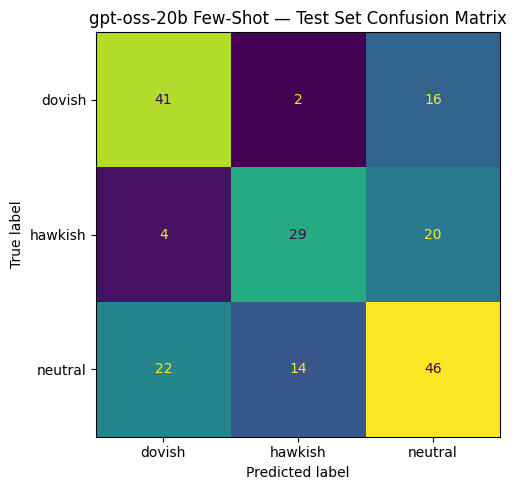


  claude46-sonnet  —  FEW-SHOT LABELING

Test set:  n=194
              precision    recall  f1-score   support

      dovish       0.74      0.76      0.75        59
     hawkish       0.69      0.45      0.55        53
     neutral       0.60      0.72      0.66        82

    accuracy                           0.66       194
   macro avg       0.68      0.65      0.65       194
weighted avg       0.67      0.66      0.65       194



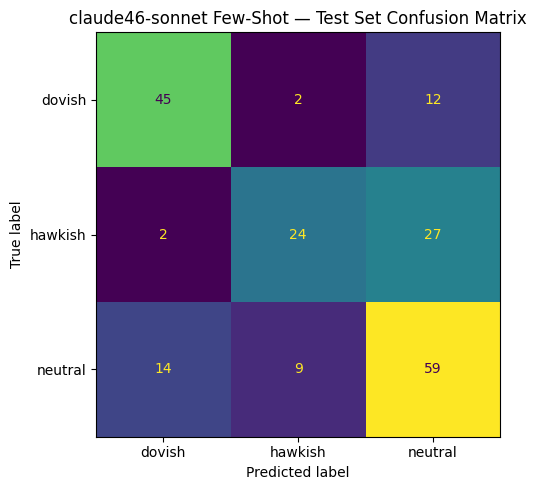


  llama33-70b-br  —  FEW-SHOT LABELING

Test set:  n=194
              precision    recall  f1-score   support

      dovish       0.70      0.73      0.72        59
     hawkish       0.65      0.49      0.56        53
     neutral       0.58      0.66      0.62        82

    accuracy                           0.63       194
   macro avg       0.65      0.63      0.63       194
weighted avg       0.64      0.63      0.63       194



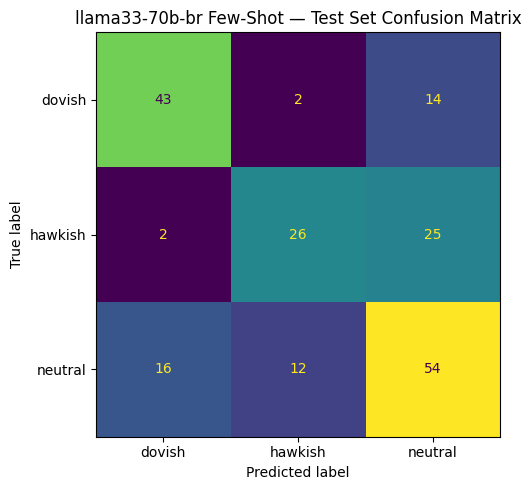


  gpt-oss-120b-br  —  FEW-SHOT LABELING

Test set:  n=194
              precision    recall  f1-score   support

      dovish       0.61      0.85      0.71        59
     hawkish       0.59      0.66      0.62        53
     neutral       0.64      0.41      0.50        82

    accuracy                           0.61       194
   macro avg       0.61      0.64      0.61       194
weighted avg       0.62      0.61      0.60       194



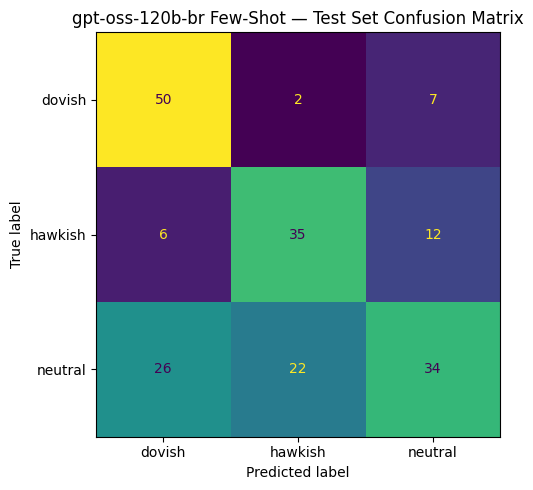


  claude46-opus  —  FEW-SHOT LABELING

Test set:  n=194
              precision    recall  f1-score   support

      dovish       0.71      0.83      0.77        59
     hawkish       0.67      0.45      0.54        53
     neutral       0.61      0.66      0.63        82

    accuracy                           0.65       194
   macro avg       0.66      0.65      0.65       194
weighted avg       0.65      0.65      0.65       194



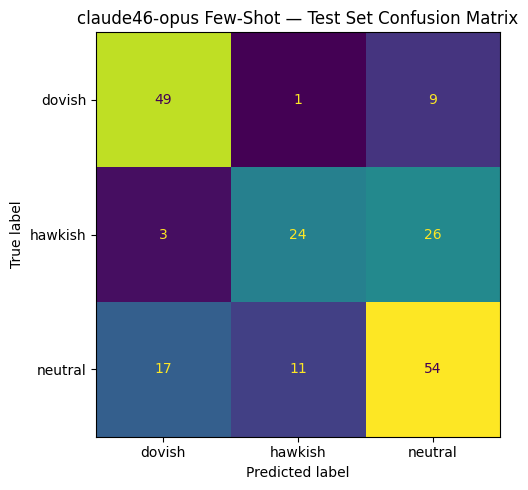

In [105]:
# ── LLM Stance Labeling — Results ─────────────────────────────────────────────
# Loads results for every model in GROQ_MODELS + BEDROCK_MODELS from llm_outputs/{slug}/.
# Reconstructs (y_true, y_pred) from the checkpoint CSV + test_df so confusion matrices
# are always available, even after a kernel restart.
# Pre-computed results from prior runs are loaded regardless of which backend produced them.

llm_results = {}
llm_preds_d = llm_preds_d if 'llm_preds_d' in globals() else {}
llm_corpus  = llm_corpus  if 'llm_corpus'  in globals() else {}

_all_llm_models = list(GROQ_MODELS) + list(BEDROCK_MODELS)

for m in _all_llm_models:
    slug      = m['slug']
    ckpt_path = f'./llm_outputs/{slug}/labels_checkpoint.csv'
    rpt_path  = f'./llm_outputs/{slug}/llm_test_report.csv'
    corp_path = f'./llm_outputs/{slug}/fomc_labeled_full.csv'

    # Full corpus (load once per slug)
    for p in [corp_path, ckpt_path]:
        if os.path.exists(p) and slug not in llm_corpus:
            llm_corpus[slug] = pd.read_csv(p)
            break

    # Reconstruct (y_true, y_pred) from checkpoint CSV
    if os.path.exists(ckpt_path):
        _ckpt   = pd.read_csv(ckpt_path)
        _merged = test_df[['sentence', 'label']].merge(
            _ckpt[['sentence', 'llm_label']].drop_duplicates('sentence'),
            on='sentence', how='left'
        )
        _merged['llm_label'] = _merged['llm_label'].fillna(2).astype(int)
        yt = _merged['label'].values
        yp = _merged['llm_label'].values
        llm_preds_d[slug] = (yt, yp)
        rpt_df = pd.DataFrame(
            classification_report(yt, yp, labels=[0,1,2],
                                  target_names=[ID2LABEL[i] for i in range(3)],
                                  output_dict=True, zero_division=0)
        ).T
        rpt_df.to_csv(rpt_path)
        llm_results[slug] = rpt_df
    elif os.path.exists(rpt_path):
        llm_results[slug] = pd.read_csv(rpt_path, index_col=0)
    elif slug not in llm_preds_d:
        print(f'[{slug}] No results found — run labeling cell with RUN_LLM_LABELING / RUN_BEDROCK_LABELING = True.')
        continue

print(f'LLM results loaded for: {list(llm_results.keys())}\n')

for slug in llm_results:
    rpt = llm_results[slug]
    print(f'\n{"="*70}')
    print(f'  {slug}  —  FEW-SHOT LABELING')
    print(f'{"="*70}\n')

    if slug in llm_preds_d:
        yt, yp = llm_preds_d[slug]
        print(f'Test set:  n={len(yt)}')
        print(classification_report(yt, yp, labels=[0,1,2],
                                    target_names=[ID2LABEL[i] for i in range(3)],
                                    zero_division=0))
        cm_llm = confusion_matrix(yt, yp, labels=[0,1,2])
        disp   = ConfusionMatrixDisplay(cm_llm, display_labels=[ID2LABEL[i] for i in range(3)])
        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, values_format='d', colorbar=False)
        ax.set_title(f'{slug} Few-Shot — Test Set Confusion Matrix')
        plt.tight_layout(); plt.show()
    else:
        macro_f1 = rpt.loc['macro avg', 'f1-score']
        acc      = rpt.loc['accuracy',  'f1-score']
        print(f'Accuracy: {acc:.4f}  Macro F1: {macro_f1:.4f}')
        print('(Confusion matrix unavailable — raw predictions not in session; re-run labeling cell.)')

In [106]:
# ── Select Best LLM Model for RQ2 Stance Features ─────────────────────────────
# Scans llm_outputs/*_fomc/ for available FOMC corpus labels and selects the
# model with the highest RQ1 test macro-F1 among those with ≥80% corpus coverage.
# Falls back to best partial coverage with a warning if no model meets threshold.

import glob as _glob

FOMC_CORPUS_SIZE   = 908
COVERAGE_THRESHOLD = 0.80   # require ≥80% FOMC corpus coverage for RQ2

best_llm_slug   = None
llm_fomc_labels = None

_candidates = []
for _fomc_dir in sorted(_glob.glob('./llm_outputs/*_fomc/')):
    _slug = os.path.basename(_fomc_dir.rstrip('/')).replace('_fomc', '')
    for _p in [f'{_fomc_dir}fomc_all_stance_labeled.csv',
               f'{_fomc_dir}labels_checkpoint.csv']:
        if not os.path.exists(_p):
            continue
        try:
            _df = pd.read_csv(_p)
            if 'stance_label' not in _df.columns:
                break
            _n   = len(_df)
            _cov = _n / FOMC_CORPUS_SIZE
            # RQ1 macro-F1: prefer live llm_results, fall back to saved report
            _mf1 = 0.0
            if _slug in llm_results:
                _mf1 = llm_results[_slug].loc['macro avg', 'f1-score']
            else:
                _rpt = f'./llm_outputs/{_slug}/llm_test_report.csv'
                if os.path.exists(_rpt):
                    _mf1 = pd.read_csv(_rpt, index_col=0).loc['macro avg', 'f1-score']
            _candidates.append((_slug, _mf1, _n, _cov, _p))
        except Exception:
            pass
        break

if _candidates:
    _full    = [c for c in _candidates if c[3] >= COVERAGE_THRESHOLD]
    _partial = [c for c in _candidates if c[3] <  COVERAGE_THRESHOLD]
    _pool    = _full if _full else _partial
    _best    = max(_pool, key=lambda c: c[1])
    best_llm_slug, _best_mf1, _n_labeled, _cov, _best_path = _best

    if not _full:
        print(f'WARNING: No model has ≥{COVERAGE_THRESHOLD:.0%} FOMC corpus coverage.')
        print(f'  Run labeling cells with LLM_LABEL_LIMIT=None for full coverage.')
        print(f'  Falling back to best available: {best_llm_slug}  '
              f'({_n_labeled}/{FOMC_CORPUS_SIZE} = {_cov:.0%})')
    else:
        print(f'Best LLM for RQ2: {best_llm_slug}')
        print(f'  RQ1 macro-F1 : {_best_mf1:.4f}')
        print(f'  FOMC coverage: {_n_labeled}/{FOMC_CORPUS_SIZE} ({_cov:.0%})')

    llm_fomc_labels = (pd.read_csv(_best_path)[['sentence', 'stance_label']]
                         .drop_duplicates('sentence'))
    print(f'  Stance dist  : {dict(llm_fomc_labels["stance_label"].value_counts().sort_index())}')
    print()
    print('All candidates:')
    for _s, _mf1, _n, _cv, _ in sorted(_candidates, key=lambda c: -c[1]):
        _flag = ' ← selected' if _s == best_llm_slug else ''
        print(f'  {_s:<22}  macro-F1={_mf1:.4f}  '
              f'coverage={_n}/{FOMC_CORPUS_SIZE} ({_cv:.0%}){_flag}')
else:
    print('No FOMC corpus labels found. LLM-stance features will be omitted from RQ2.')
    print('To generate: set RUN_LLM_LABELING=True or RUN_BEDROCK_LABELING=True and re-run labeling cells.')


Best LLM for RQ2: claude46-sonnet
  RQ1 macro-F1 : 0.6503
  FOMC coverage: 908/908 (100%)
  Stance dist  : {0: np.int64(180), 1: np.int64(136), 2: np.int64(592)}

All candidates:
  llama33-70b             macro-F1=0.6599  coverage=100/908 (11%)
  claude46-sonnet         macro-F1=0.6503  coverage=908/908 (100%) ← selected
  claude46-opus           macro-F1=0.6455  coverage=908/908 (100%)
  llama33-70b-br          macro-F1=0.6310  coverage=908/908 (100%)
  gpt-oss-120b            macro-F1=0.6180  coverage=100/908 (11%)
  gpt-oss-120b-br         macro-F1=0.6126  coverage=908/908 (100%)
  llama31-8b              macro-F1=0.5135  coverage=908/908 (100%)


## Phase 4 — RQ2 Event-Aggregation Pipeline

Sentence-level signals are aggregated to one row per FOMC meeting, macro controls are added, and a family of classifiers is trained to predict 3-day S&P 500 directional movement. All RQ2 runs are logged to the `CS271-RQ2-Market` MLflow experiment.

**Stance features:** Two sources are compared side-by-side:
- **GPT-4 growth stance** (`growth_stance`) — sentence-level positive/negative/neutral labels on the *growth* dimension from prior research (`fomc_market_master.csv`). Inflation and employment dimensions are excluded: inflation has no negative labels, employment is >99% neutral.
- **LLM holistic stance** (`llm_stance_score`) — hawkish/dovish/neutral labels produced by the best-performing LLM from Phase 3 (selected by RQ1 test macro-F1 with ≥80% FOMC corpus coverage). Aggregated per meeting as `pct_hawkish − pct_dovish`.

The key RQ2 question is whether LLM-generated holistic FOMC stance labels produce better directional market predictions than the GPT-4 growth-only dimensional labels from prior research.

### Step 1 — Sentence → Event Aggregation

Each FOMC meeting is collapsed to a single row. GPT-4 growth stance and LLM holistic stance labels are merged onto sentence-level records before aggregation. The stance score for both sources is computed as `pct_positive/hawkish − pct_negative/dovish`, producing a value in `[−1, +1]` where positive = hawkish meeting and negative = dovish meeting. The enriched sentence-level dataset is saved to `data/processed/master_ev_with_stance.csv`.

In [107]:
master_ev = pd.read_csv('./data/processed/fomc_market_master.csv', parse_dates=['date'])

# Merge LLM stance labels from best-performing model (selected above)
if 'llm_fomc_labels' in globals() and llm_fomc_labels is not None:
    master_ev = master_ev.merge(llm_fomc_labels, on='sentence', how='left')
    _n_matched = master_ev['stance_label'].notna().sum()
    print(f'LLM stance labels merged: {_n_matched}/{len(master_ev)} sentences matched '
          f'({_n_matched/len(master_ev):.1%})  [model: {best_llm_slug}]')
else:
    master_ev['stance_label'] = np.nan
    print('No LLM stance labels available — llm_stance_score will be NaN in event_df.')

def _pct(s, v):      return (s == v).mean() if len(s) > 0 else 0.0
def _score(s, p, n): return _pct(s, p) - _pct(s, n)

# NaN-safe variants for LLM labels (partial coverage handled per-event)
def _pct_llm(s, v):
    valid = s.dropna()
    return (valid == v).mean() if len(valid) > 0 else np.nan
def _score_llm(s, p, n):
    valid = s.dropna()
    return (_pct(valid, p) - _pct(valid, n)) if len(valid) > 0 else np.nan

event_df = (
    master_ev.groupby('date', sort=True)
    .agg(
        n_sentences        = ('sentence',                      'count'),
        pct_pos_finbert    = ('prediction_finbert',            lambda x: _pct(x, 'positive')),
        pct_neg_finbert    = ('prediction_finbert',            lambda x: _pct(x, 'negative')),
        sentiment_score_fb = ('prediction_finbert',            lambda x: _score(x, 'positive', 'negative')),
        vader_mean         = ('sentiment_vader_compound_score','mean'),
        # GPT-4 growth stance only — inflation has no negative labels; employment is ~all neutral
        growth_stance      = ('growth_sentiment_gpt4',         lambda x: _score(x, 'positive', 'negative')),
        # LLM holistic hawkish/dovish score
        llm_pct_hawkish    = ('stance_label',                  lambda x: _pct_llm(x, 1)),
        llm_pct_dovish     = ('stance_label',                  lambda x: _pct_llm(x, 0)),
        llm_stance_score   = ('stance_label',                  lambda x: _score_llm(x, 1, 0)),
        target_3d          = ('target_direction',              'first'),
    )
    .reset_index()
)
print(f'Event-level dataset: {len(event_df)} FOMC meetings')
_llm_non_nan = event_df['llm_stance_score'].notna().sum()
print(f'llm_stance_score non-NaN events: {_llm_non_nan}/{len(event_df)} ({_llm_non_nan/len(event_df):.0%})')
print(event_df[['date','n_sentences','sentiment_score_fb','growth_stance',
                'llm_stance_score','target_3d']].head(5).to_string())

# Save enriched sentence-level dataset
master_ev.to_csv('./data/processed/master_ev_with_stance.csv', index=False)
print(f'Saved master_ev_with_stance.csv ({len(master_ev)} rows)')

LLM stance labels merged: 908/908 sentences matched (100.0%)  [model: claude46-sonnet]
Event-level dataset: 131 FOMC meetings
llm_stance_score non-NaN events: 131/131 (100%)
        date  n_sentences  sentiment_score_fb  growth_stance  llm_stance_score  target_3d
0 2006-01-03            5            0.800000       0.800000          0.200000          1
1 2006-02-21            8            0.250000       0.250000          0.375000          1
2 2006-04-18           10            0.500000       0.500000          0.400000          1
3 2006-05-31           12            0.000000      -0.083333          0.083333          0
4 2006-07-20            6            0.333333       0.166667          0.500000          1
Saved master_ev_with_stance.csv (908 rows)


### Step 2 — Market Outcome (3-day primary; 10-day for robustness)

In [108]:
spy2 = yf.download('SPY', start='2006-01-01', end='2025-01-01', auto_adjust=True, progress=False)
if isinstance(spy2.columns, pd.MultiIndex): spy2.columns = spy2.columns.get_level_values(0)
spy2['10d_ret']    = spy2['Close'].pct_change(10).shift(-10)
spy2['target_10d'] = (spy2['10d_ret'] > 0).astype(int)
spy_10d = spy2[['target_10d']].reset_index()
spy_10d.columns = ['date', 'target_10d']
spy_10d['date'] = pd.to_datetime(spy_10d['date'])
event_df['date'] = pd.to_datetime(event_df['date'])
event_df = event_df.merge(spy_10d, on='date', how='left')
print('3d:', event_df['target_3d'].value_counts().to_dict(),
      ' | 10d:', event_df['target_10d'].value_counts().to_dict())

3d: {1: 80, 0: 51}  | 10d: {1: 86, 0: 45}


### Step 3 — Macro Controls (CPI YoY, Unemployment from FRED)

Macro series are fetched from FRED and merged onto the event-level dataset. The fully built `event_df` (all sentiment, stance, market, and macro features) is saved to `data/processed/event_df.csv`; raw series are saved to `macro_cpi.csv` and `macro_unrate.csv` in the same directory.

In [109]:
def _fred(series_id):
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
    df  = pd.read_csv(io.StringIO(requests.get(url, timeout=30).text))
    date_col = 'observation_date' if 'observation_date' in df.columns else 'DATE'
    df = df.rename(columns={date_col: 'date'})
    df['date'] = pd.to_datetime(df['date'])
    df = df[df[series_id] != '.'].copy()
    df[series_id] = df[series_id].astype(float)
    return df.sort_values('date').reset_index(drop=True)

cpi_raw = _fred('CPIAUCSL')
unrate  = _fred('UNRATE')
cpi_raw['CPI_yoy'] = cpi_raw['CPIAUCSL'].pct_change(12) * 100
cpi = cpi_raw[['date','CPI_yoy']].dropna()

ev_s   = event_df.sort_values('date')
cpi_a  = pd.merge_asof(ev_s[['date']], cpi,                       on='date', direction='backward')
unr_a  = pd.merge_asof(ev_s[['date']], unrate[['date','UNRATE']], on='date', direction='backward')
event_df = event_df.merge(cpi_a, on='date', how='left').merge(unr_a, on='date', how='left')
print(f'NaN CPI_yoy: {event_df["CPI_yoy"].isna().sum()}  NaN UNRATE: {event_df["UNRATE"].isna().sum()}')
print(event_df[['date','CPI_yoy','UNRATE','target_3d']].tail(4).to_string())

# Save fully-built event-level dataset and raw macro series
event_df.to_csv('./data/processed/event_df.csv', index=False)
cpi.to_csv('./data/processed/macro_cpi.csv', index=False)
unrate[['date','UNRATE']].to_csv('./data/processed/macro_unrate.csv', index=False)
print(f'Saved event_df.csv ({len(event_df)} events), macro_cpi.csv, macro_unrate.csv')

NaN CPI_yoy: 0  NaN UNRATE: 0
          date   CPI_yoy  UNRATE  target_3d
127 2022-10-12  7.758814     3.6          1
128 2022-11-23  7.122856     3.6          0
129 2023-01-04  6.327179     3.5          1
130 2023-02-22  5.957821     3.6          0
Saved event_df.csv (131 events), macro_cpi.csv, macro_unrate.csv


### Step 4 — RQ2 Comparison Models

Logistic Regression and Random Forest classifiers are evaluated across feature sets designed to isolate the marginal contribution of each stance source. The temporal train and test splits are saved to `data/processed/event_train.csv` and `data/processed/event_test.csv`. Key comparisons:

| Comparison | Feature sets |
|---|---|
| Generic sentiment vs LLM stance | `Macro + Generic Sentiment` vs `Macro + LLM Stance` |
| GPT-4 growth vs LLM holistic | `Macro + Growth Stance` vs `Macro + LLM Stance` |
| Full models | `Macro + Sent + Growth Stance` vs `Macro + Sent + LLM Stance` |
| Combined stance | `Macro + Sent + All Stance` (GPT-4 + LLM together) |

LLM-stance feature sets are only included when FOMC corpus labels are available (guarded by `_llm_available`). If no labeled FOMC corpus exists, the pipeline runs with GPT-4 growth stance only.

In [110]:
mlflow.set_experiment('CS271-RQ2-Market')

_ev_dates = sorted(event_df['date'].unique())
cutoff_ev = _ev_dates[int(len(_ev_dates) * 0.80)]
_req      = ['target_3d','CPI_yoy','UNRATE']
train_ev  = event_df[event_df['date'] <  cutoff_ev].dropna(subset=_req).copy()
test_ev   = event_df[event_df['date'] >= cutoff_ev].dropna(subset=_req).copy()
y_train_ev, y_test_ev = train_ev['target_3d'].values, test_ev['target_3d'].values
print(f'Event split — train: {len(train_ev)}  test: {len(test_ev)}  cutoff: {pd.Timestamp(cutoff_ev).date()}')

MACRO      = ['CPI_yoy','UNRATE']
GEN_SENT   = ['sentiment_score_fb','vader_mean']
STANCE     = ['growth_stance']        # GPT-4 growth dimension only (inflation: no negative labels; employment: ~all neutral)
LLM_STANCE = ['llm_stance_score']     # LLM holistic hawkish/dovish score

_llm_available = (
    'llm_stance_score' in event_df.columns and
    train_ev['llm_stance_score'].notna().sum() > 0 and
    test_ev['llm_stance_score'].notna().sum() > 0
)
if _llm_available:
    _llm_slug_info = best_llm_slug if 'best_llm_slug' in globals() and best_llm_slug else 'unknown'
    print(f'LLM-stance available ({_llm_slug_info}): '
          f'train={train_ev["llm_stance_score"].notna().sum()}/{len(train_ev)}  '
          f'test={test_ev["llm_stance_score"].notna().sum()}/{len(test_ev)}')
else:
    print('LLM-stance not available — LLM feature sets will be skipped.')

def _lr_pipe(X_tr, X_te, y_tr, y_te):
    p = Pipeline([('sc', StandardScaler()),
                  ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))])
    p.fit(X_tr, y_tr); return accuracy_score(y_te, p.predict(X_te)), p

majority_ev = max(y_test_ev.mean(), 1 - y_test_ev.mean())

# Build feature specs — LLM entries inserted for direct comparison with Macro+GenSent and Macro+Growth Stance
feature_specs = (
    [
        ('Majority class',               None),
        ('Macro only',                   MACRO),
        ('Macro + Generic Sentiment',    MACRO + GEN_SENT),      # baseline: compares directly with LLM Stance below
        ('Macro + Growth Stance',        MACRO + STANCE),        # GPT-4 growth stance
    ] + ([
        ('Macro + LLM Stance',           MACRO + LLM_STANCE),   # LLM holistic stance — compare with two rows above
    ] if _llm_available else []) + [
        ('Macro + Sent + Growth Stance', MACRO + GEN_SENT + STANCE),
    ] + ([
        ('Macro + Sent + LLM Stance',    MACRO + GEN_SENT + LLM_STANCE),
        ('Macro + Sent + All Stance',    MACRO + GEN_SENT + STANCE + LLM_STANCE),
    ] if _llm_available else []) + [
        ('Sent + Growth Stance only',    GEN_SENT + STANCE),
    ]
)

def _rq2_slug(name):
    return 'rq2_' + name.lower().replace(' + ','_').replace(' ','_').replace('(','').replace(')','')

rq2_results = {}
for name, feats in feature_specs:
    with mlflow.start_run(run_name=_rq2_slug(name)):
        mlflow.log_params({'model': 'LogisticRegression', 'feature_set': name,
                           'llm_model': best_llm_slug if _llm_available and 'LLM' in name else 'n/a'})
        if feats is None:
            _maj = int(y_train_ev.mean() >= 0.5)
            acc  = accuracy_score(y_test_ev, np.full(len(y_test_ev), _maj))
        else:
            acc, _ = _lr_pipe(train_ev[feats].fillna(0).values,
                               test_ev[feats].fillna(0).values,
                               y_train_ev, y_test_ev)
        mlflow.log_metrics({'test_accuracy': acc, 'majority_baseline': majority_ev,
                            'lift': acc - majority_ev})
        rq2_results[name] = acc
        print(f'  {name:<45}  acc={acc:.4f}')

# Random Forest — Growth Stance
with mlflow.start_run(run_name='rq2_rf_growth_stance'):
    _rf_feats = MACRO + GEN_SENT + STANCE
    mlflow.log_params({'model': 'RandomForest', 'n_estimators': 200,
                       'feature_set': 'Macro+Sent+Growth Stance'})
    rf = Pipeline([('sc', StandardScaler()),
                   ('rf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED,
                                                 class_weight='balanced'))])
    rf.fit(train_ev[_rf_feats].fillna(0).values, y_train_ev)
    rf_preds = rf.predict(test_ev[_rf_feats].fillna(0).values)
    rf_acc   = accuracy_score(y_test_ev, rf_preds)
    mlflow.log_metrics({'test_accuracy': rf_acc, 'majority_baseline': majority_ev,
                        'lift': rf_acc - majority_ev})
rq2_results['RF (Macro+Sent+Growth Stance)'] = rf_acc
print(f'  {"RF (Macro+Sent+Growth Stance)":<45}  acc={rf_acc:.4f}')

# Random Forest — LLM Stance (only if available)
rf_llm_preds, rf_llm_acc = None, None
if _llm_available:
    with mlflow.start_run(run_name='rq2_rf_llm_stance'):
        _rf_llm_feats = MACRO + GEN_SENT + LLM_STANCE
        mlflow.log_params({'model': 'RandomForest', 'n_estimators': 200,
                           'feature_set': 'Macro+Sent+LLM Stance',
                           'llm_model': best_llm_slug})
        rf_llm = Pipeline([('sc', StandardScaler()),
                            ('rf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED,
                                                          class_weight='balanced'))])
        rf_llm.fit(train_ev[_rf_llm_feats].fillna(0).values, y_train_ev)
        rf_llm_preds = rf_llm.predict(test_ev[_rf_llm_feats].fillna(0).values)
        rf_llm_acc   = accuracy_score(y_test_ev, rf_llm_preds)
        mlflow.log_metrics({'test_accuracy': rf_llm_acc, 'majority_baseline': majority_ev,
                            'lift': rf_llm_acc - majority_ev})
    rq2_results['RF (Macro+Sent+LLM Stance)'] = rf_llm_acc
    print(f'  {"RF (Macro+Sent+LLM Stance)":<45}  acc={rf_llm_acc:.4f}')

# Save event-level temporal splits
train_ev.to_csv('./data/processed/event_train.csv', index=False)
test_ev.to_csv('./data/processed/event_test.csv', index=False)
print(f'Saved event_train.csv ({len(train_ev)} events), event_test.csv ({len(test_ev)} events)')

Event split — train: 104  test: 27  cutoff: 2019-11-20
LLM-stance available (claude46-sonnet): train=104/104  test=27/27
  Majority class                                 acc=0.6667
  Macro only                                     acc=0.5926
  Macro + Generic Sentiment                      acc=0.6296
  Macro + Growth Stance                          acc=0.5926
  Macro + LLM Stance                             acc=0.5926
  Macro + Sent + Growth Stance                   acc=0.6296
  Macro + Sent + LLM Stance                      acc=0.5926
  Macro + Sent + All Stance                      acc=0.5926
  Sent + Growth Stance only                      acc=0.6296
  RF (Macro+Sent+Growth Stance)                  acc=0.5926
  RF (Macro+Sent+LLM Stance)                     acc=0.6296
Saved event_train.csv (104 events), event_test.csv (27 events)


RQ2 Event-Level Results (3-day target, temporal test set):

                        Model  Accuracy
               Majority class  0.666667
    Macro + Generic Sentiment  0.629630
 Macro + Sent + Growth Stance  0.629630
    Sent + Growth Stance only  0.629630
   RF (Macro+Sent+LLM Stance)  0.629630
                   Macro only  0.592593
        Macro + Growth Stance  0.592593
           Macro + LLM Stance  0.592593
    Macro + Sent + LLM Stance  0.592593
    Macro + Sent + All Stance  0.592593
RF (Macro+Sent+Growth Stance)  0.592593


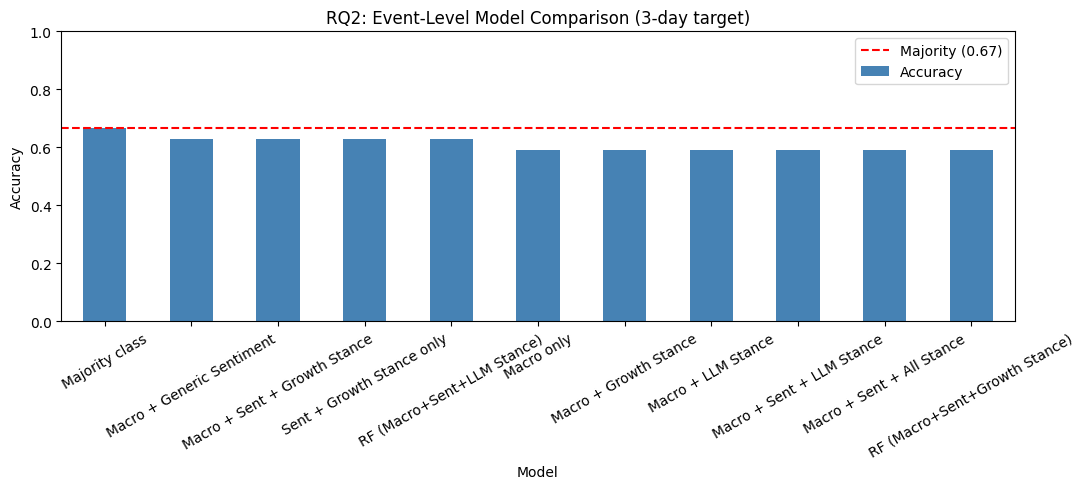

Saved rq2_results_3d.csv


In [111]:
rq2_ev_df = (
    pd.DataFrame(list(rq2_results.items()), columns=['Model','Accuracy'])
    .sort_values('Accuracy', ascending=False).reset_index(drop=True)
)
print('RQ2 Event-Level Results (3-day target, temporal test set):\n')
print(rq2_ev_df.to_string(index=False))

ax = rq2_ev_df.set_index('Model')['Accuracy'].plot(kind='bar', figsize=(11,5), rot=30, color='steelblue')
ax.axhline(majority_ev, color='red', linestyle='--', label=f'Majority ({majority_ev:.2f})')
ax.set_ylim(0,1); ax.set_ylabel('Accuracy'); ax.legend()
ax.set_title('RQ2: Event-Level Model Comparison (3-day target)')
plt.tight_layout(); plt.show()

rq2_ev_df.to_csv('./data/processed/rq2_results_3d.csv', index=False)
print('Saved data/processed/rq2_results_3d.csv')

## Phase 4 — Required Experiments

### Robustness Testing

**(A)** RQ2 with a 10-trading-day prediction horizon → results saved to `data/processed/robustness_a_horizon.csv`.  
**(B)** RQ2 evaluated on temporal sub-periods (different market regimes) → results saved to `data/processed/robustness_b_subperiod.csv`.  
**(C)** RQ1 TF-IDF+LR on truncated sentences (simulated corrupted/OOD input) → results saved to `data/processed/robustness_c_truncation.csv`.

In [112]:
# (A) 10-day horizon
train_10d = train_ev.dropna(subset=['target_10d'])
test_10d  = test_ev.dropna(subset=['target_10d'])
y_tr10, y_te10 = train_10d['target_10d'].values, test_10d['target_10d'].values

_rob_a_specs = [
    ('Majority class',               None),
    ('Macro only',                   MACRO),
    ('Macro + Sent + Growth Stance', MACRO + GEN_SENT + STANCE),
]
if _llm_available:
    _rob_a_specs.append(('Macro + Sent + LLM Stance', MACRO + GEN_SENT + LLM_STANCE))

rob_a_rows = []
print('Robustness A — 3d vs 10d prediction horizon')
print(f'{"Model":<40}  {"3d acc":>8}  {"10d acc":>9}  {"delta":>7}')
print('-'*70)
for name, feats in _rob_a_specs:
    if feats is None:
        a3  = accuracy_score(y_test_ev, np.full(len(y_test_ev), int(y_train_ev.mean() >= .5)))
        a10 = accuracy_score(y_te10,    np.full(len(y_te10),    int(y_tr10.mean()    >= .5)))
    else:
        a3,  _ = _lr_pipe(train_ev[feats].fillna(0).values,  test_ev[feats].fillna(0).values,
                           y_train_ev, y_test_ev)
        a10, _ = _lr_pipe(train_10d[feats].fillna(0).values, test_10d[feats].fillna(0).values,
                           y_tr10, y_te10)
    print(f'  {name:<38}  {a3:>8.4f}  {a10:>9.4f}  {a10-a3:>+7.4f}')
    rob_a_rows.append({'model': name, 'acc_3d': round(a3, 4),
                       'acc_10d': round(a10, 4), 'delta_10d_minus_3d': round(a10-a3, 4)})

rob_a_df = pd.DataFrame(rob_a_rows)
rob_a_df.to_csv('./data/processed/robustness_a_horizon.csv', index=False)
print('Saved data/processed/robustness_a_horizon.csv')

Robustness A — 3d vs 10d prediction horizon
Model                                       3d acc    10d acc    delta
----------------------------------------------------------------------
  Majority class                            0.6667     0.7037  +0.0370
  Macro only                                0.5926     0.7778  +0.1852
  Macro + Sent + Growth Stance              0.6296     0.7037  +0.0741
  Macro + Sent + LLM Stance                 0.5926     0.6296  +0.0370
Saved robustness_a_horizon.csv


In [113]:
# (B) Temporal sub-period robustness
_rob_b_specs = [('Macro+Sent+Growth Stance', MACRO + GEN_SENT + STANCE)]
if _llm_available:
    _rob_b_specs.append(('Macro+Sent+LLM Stance', MACRO + GEN_SENT + LLM_STANCE))

rob_b_rows = []
for _feat_label, _f in _rob_b_specs:
    print(f'\nRobustness B — Sub-periods ({_feat_label}, LR)')
    print(f'{"Period":<28}  {"n":>4}  {"acc":>6}  {"majority":>8}')
    print('-'*52)
    for label, lo, hi in [
        ('Pre-2016',         '2006-01-01', '2016-01-01'),
        ('2016-2019',        '2016-01-01', '2020-01-01'),
        ('COVID 2020-2022',  '2020-01-01', '2023-01-01'),
        ('Full test window', str(pd.Timestamp(cutoff_ev).date()), '2099-01-01'),
    ]:
        sub = event_df[(event_df['date'] >= lo) & (event_df['date'] < hi)].dropna(subset=_req)
        if len(sub) < 8:
            print(f'  {label:<26}  n={len(sub):3d}  (skipped)'); continue
        acc, _ = _lr_pipe(train_ev[_f].fillna(0).values, sub[_f].fillna(0).values,
                          y_train_ev, sub['target_3d'].values)
        maj = max(sub['target_3d'].mean(), 1 - sub['target_3d'].mean())
        print(f'  {label:<26}  n={len(sub):3d}  {acc:.4f}  {maj:.4f}')
        rob_b_rows.append({'feature_set': _feat_label, 'period': label,
                           'n': len(sub), 'acc': round(acc, 4), 'majority': round(maj, 4)})

rob_b_df = pd.DataFrame(rob_b_rows)
rob_b_df.to_csv('./data/processed/robustness_b_subperiod.csv', index=False)
print('Saved data/processed/robustness_b_subperiod.csv')


Robustness B — Sub-periods (Macro+Sent+Growth Stance, LR)
Period                           n     acc  majority
----------------------------------------------------
  Pre-2016                    n= 73  0.5890  0.5890
  2016-2019                   n= 32  0.5938  0.6250
  COVID 2020-2022             n= 24  0.6250  0.6667
  Full test window            n= 27  0.6296  0.6667

Robustness B — Sub-periods (Macro+Sent+LLM Stance, LR)
Period                           n     acc  majority
----------------------------------------------------
  Pre-2016                    n= 73  0.6301  0.5890
  2016-2019                   n= 32  0.6250  0.6250
  COVID 2020-2022             n= 24  0.5833  0.6667
  Full test window            n= 27  0.5926  0.6667
Saved robustness_b_subperiod.csv


In [114]:
# (C) RQ1 input truncation
if 'y_pred_tfidf' not in globals() or 'log_reg' not in globals() or 'tfidf' not in globals():
    tfidf         = TfidfVectorizer(max_features=1000)
    X_train_tfidf = tfidf.fit_transform(train_df['sentence'])
    X_test_tfidf  = tfidf.transform(test_df['sentence'])
    log_reg       = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    log_reg.fit(X_train_tfidf, train_df['label'])
    y_pred_tfidf  = log_reg.predict(X_test_tfidf)
base_acc = accuracy_score(test_df['label'], y_pred_tfidf)
rob_c_rows = [{'truncation': 'full', 'n_chars': None,
               'acc': round(base_acc, 4), 'delta': 0.0}]
print('Robustness C — TF-IDF+LR on truncated inputs (OOD simulation)')
print(f'  Full sentences:       acc={base_acc:.4f}')
for trunc in [200, 100, 50, 25]:
    acc = accuracy_score(test_df['label'], log_reg.predict(tfidf.transform(test_df['sentence'].str[:trunc])))
    print(f'  First {trunc:>3d} chars only: acc={acc:.4f}  delta={acc-base_acc:+.4f}')
    rob_c_rows.append({'truncation': f'first_{trunc}_chars', 'n_chars': trunc,
                       'acc': round(acc, 4), 'delta': round(acc - base_acc, 4)})

rob_c_df = pd.DataFrame(rob_c_rows)
rob_c_df.to_csv('./data/processed/robustness_c_truncation.csv', index=False)
print('Saved data/processed/robustness_c_truncation.csv')

Robustness C — TF-IDF+LR on truncated inputs (OOD simulation)
  Full sentences:       acc=0.5567
  First 200 chars only: acc=0.5412  delta=-0.0155
  First 100 chars only: acc=0.5000  delta=-0.0567
  First  50 chars only: acc=0.4278  delta=-0.1289
  First  25 chars only: acc=0.4227  delta=-0.1340
Saved robustness_c_truncation.csv


### Error Analysis (RQ1)

Qualitative inspection of FinBERT fine-tuned misclassifications on the 194-sentence test set. The confusion breakdown identifies which class pairs are most conflated; example sentences illustrate the hypothesized failure modes.

In [115]:
# fb_preds and fb_true are set by the unified BERT results cell.
if 'fb_preds' not in globals() or len(fb_preds) == 0:
    _fb_cfg  = next((m for m in BERT_MODELS if m['slug'] == 'finbert'), None)
    fb_preds = (np.load(_fb_cfg['preds'])
                if _fb_cfg and os.path.exists(_fb_cfg['preds']) else np.array([]))
    fb_true  = np.array(test_df['label'])
if len(fb_preds) == 0:
    raise RuntimeError('No FinBERT predictions found. Run the BERT training cell with RUN_BERT_TRAINING=True first.')
fb_sents = test_df['sentence'].reset_index(drop=True).values

wrong    = fb_preds != fb_true
wrong_df = pd.DataFrame({
    'sentence':   fb_sents[wrong],
    'true':       [ID2LABEL[l] for l in fb_true[wrong]],
    'predicted':  [ID2LABEL[p] for p in fb_preds[wrong]],
    'error_type': [f'{ID2LABEL[t]}->{ID2LABEL[p]}'
                   for t, p in zip(fb_true[wrong], fb_preds[wrong])],
})
print(f'FinBERT fine-tuned — Errors: {wrong.sum()} / {len(fb_true)} ({wrong.mean()*100:.1f}%)')
print('\nConfusion type breakdown:')
print(wrong_df['error_type'].value_counts().to_string())

for etype in wrong_df['error_type'].value_counts().head(3).index:
    sub = wrong_df[wrong_df['error_type'] == etype]
    print(f'\n── {etype} (n={len(sub)}) ──')
    for _, row in sub.head(3).iterrows():
        print(f'  [{row["true"]} -> {row["predicted"]}]')
        print(f'  {row["sentence"][:180]}')
        print()

FinBERT fine-tuned — Errors: 93 / 194 (47.9%)

Confusion type breakdown:
error_type
neutral->dovish     26
hawkish->dovish     22
dovish->hawkish     16
hawkish->neutral    12
neutral->hawkish     9
dovish->neutral      8

── neutral->dovish (n=26) ──
  [neutral -> dovish]
  Nonetheless, those restraining influences were expected to abate over time and economic activity strengthen gradually.

  [neutral -> dovish]
  An easing of supply constraints was expected to support continued gains in economic activity and employment as well as a reduction in inflation.

  [neutral -> dovish]
  Market sentiment toward the syndicated leveraged loan market also improved, with the average bid price increasing noticeably and bid-asked spreads narrowing a bit further.


── hawkish->dovish (n=22) ──
  [hawkish -> dovish]
  The vote also encompassed approval of the sentence below for inclusion in the press statement to be released shortly after the meeting: Against the background of its long-run goals

 

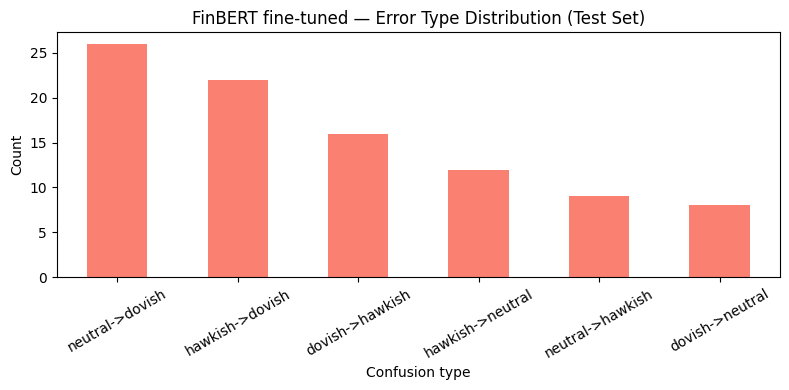

In [116]:
fig, ax = plt.subplots(figsize=(8, 4))
wrong_df['error_type'].value_counts().plot(kind='bar', ax=ax, color='salmon')
ax.set_title('FinBERT fine-tuned — Error Type Distribution (Test Set)')
ax.set_xlabel('Confusion type'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


### Inference Efficiency

Wall-clock inference time on the 194-sentence test set (CPU). TF-IDF+LR and TF-IDF+SVM each averaged over 100 reps (full pipeline: vectorize + predict); FinBERT-FOMC single batched pass; event-level LR over 1 000 reps. LLM backends (Groq and AWS Bedrock) are network-bound and are not benchmarked locally. LLM backends (Groq and AWS Bedrock) are network-bound and are not benchmarked locally.

In [117]:
import time as _t
_sents  = test_df['sentence'].tolist()
_Xtfidf = tfidf.transform(_sents)

# Full pipeline: vectorize + predict (same basis as SVM below)
t0 = _t.perf_counter()
for _ in range(100):
    _X = tfidf.transform(_sents)
    log_reg.predict(_X)
tfidf_ms = (_t.perf_counter()-t0)/100*1000

# SVM pipeline includes its own TF-IDF transform
t0 = _t.perf_counter()
for _ in range(100): svm_clf.predict(_sents)
svm_ms = (_t.perf_counter()-t0)/100*1000

bert_ms = float('nan')
# Build FinBERT-FOMC pipeline on demand if not already in session
if 'fomc_pipeline' not in globals() or fomc_pipeline is None:
    _fomc_timing_cfg = next((m for m in BERT_MODELS if m['slug'] == 'finbert-fomc'), None)
    if _fomc_timing_cfg:
        try:
            fomc_pipeline = hf_pipeline(
                'text-classification', model=_fomc_timing_cfg['id'],
                tokenizer=_fomc_timing_cfg['id'],
                truncation=True, max_length=MAX_LENGTH,
                device=0 if device == 'cuda' else -1
            )
        except Exception as _e:
            fomc_pipeline = None
            print(f'FinBERT-FOMC pipeline load skipped: {_e}')
try:
    if fomc_pipeline is not None:
        t0 = _t.perf_counter()
        _  = fomc_pipeline(_sents, batch_size=32)
        bert_ms = (_t.perf_counter()-t0)*1000
    else:
        print('FinBERT-FOMC timing skipped: pipeline not available.')
except Exception as _e:
    print(f'FinBERT-FOMC timing skipped: {_e}')

_sc2 = StandardScaler().fit(train_ev[MACRO+GEN_SENT+STANCE].values)
_lr2 = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED).fit(
    _sc2.transform(train_ev[MACRO+GEN_SENT+STANCE].values), y_train_ev)
_Xev = _sc2.transform(test_ev[MACRO+GEN_SENT+STANCE].values)
t0 = _t.perf_counter()
for _ in range(1000): _lr2.predict(_Xev)
lr_ms = (_t.perf_counter()-t0)/1000*1000

n = len(_sents)
print(f'{"Model":<38}  {"Total ms":>10}  {"Per-sentence":>14}')
print('-'*68)
print(f'{"TF-IDF + Logistic Regression":<38}  {tfidf_ms:>10.2f}  {tfidf_ms/n*1000:>11.2f} us')
print(f'{"TF-IDF + SVM":<38}  {svm_ms:>10.2f}  {svm_ms/n*1000:>11.2f} us')
if not np.isnan(bert_ms):
    print(f'{"FinBERT-FOMC zero-shot (CPU)":<38}  {bert_ms:>10.1f}  {bert_ms/n*1000:>11.1f} us')
print(f'{"Event-level LR (RQ2)":<38}  {lr_ms:>10.3f}  {lr_ms/max(len(test_ev),1)*1000:>11.3f} us')
print('LLM via Groq API:        ~40–80  ms/sentence  (network-bound, not benchmarked locally)')
print('LLM via AWS Bedrock:    ~50–150 ms/sentence  (network-bound, varies by model and region)')

Model                                     Total ms    Per-sentence
--------------------------------------------------------------------
TF-IDF + Logistic Regression                  2.61        13.48 us
TF-IDF + SVM                                 16.19        83.46 us
FinBERT-FOMC zero-shot (CPU)                3087.9      15916.9 us
Event-level LR (RQ2)                         0.023        0.856 us
LLM via Groq API:        ~40–80  ms/sentence  (network-bound, not benchmarked locally)
LLM via AWS Bedrock:    ~50–150 ms/sentence  (network-bound, varies by model and region)


## Phase 4 — Final Results Summary with Bootstrap Confidence Intervals

All numbers from the held-out **test set** (never used for model selection). 95% bootstrap CIs computed over 2 000 resamples of the test set predictions. RQ1 ranked by macro-F1; RQ2 ranked by accuracy. The RQ2 final table (with CIs) is saved to `data/processed/rq2_results_final_with_ci.csv`; the RQ2 accuracy comparison (without CIs) is saved to `data/processed/rq2_results_3d.csv`.

RQ1 — Stance Classification (test n=194, 95% bootstrap CI on macro-F1)

  claude46-sonnet few-shot                acc=0.6598  mF1=0.6503  95% CI=n/a
  claude46-opus few-shot                  acc=0.6546  mF1=0.6455  95% CI=n/a
  llama33-70b-br few-shot                 acc=0.6340  mF1=0.6310  95% CI=n/a
  bert-uncased fine-tuned (best)          acc=0.6186  mF1=0.6223  95% CI=[0.2687, 0.4003]
  gpt-oss-120b-br few-shot                acc=0.6134  mF1=0.6126  95% CI=n/a
  gpt-oss-20b few-shot                    acc=0.5979  mF1=0.6012  95% CI=n/a
  distilbert fine-tuned (best)            acc=0.5670  mF1=0.5415  95% CI=[0.2569, 0.3947]
  TF-IDF + Logistic Regression            acc=0.5567  mF1=0.5233  95% CI=[0.2562, 0.3851]
  finbert fine-tuned (best)               acc=0.5206  mF1=0.5052  95% CI=[0.2619, 0.3956]
  TF-IDF + SVM                            acc=0.5103  mF1=0.5011  95% CI=[0.2648, 0.3961]
  finbert-fomc zero-shot                  acc=0.4588  mF1=0.4506  95% CI=[0.2572, 0.3861]


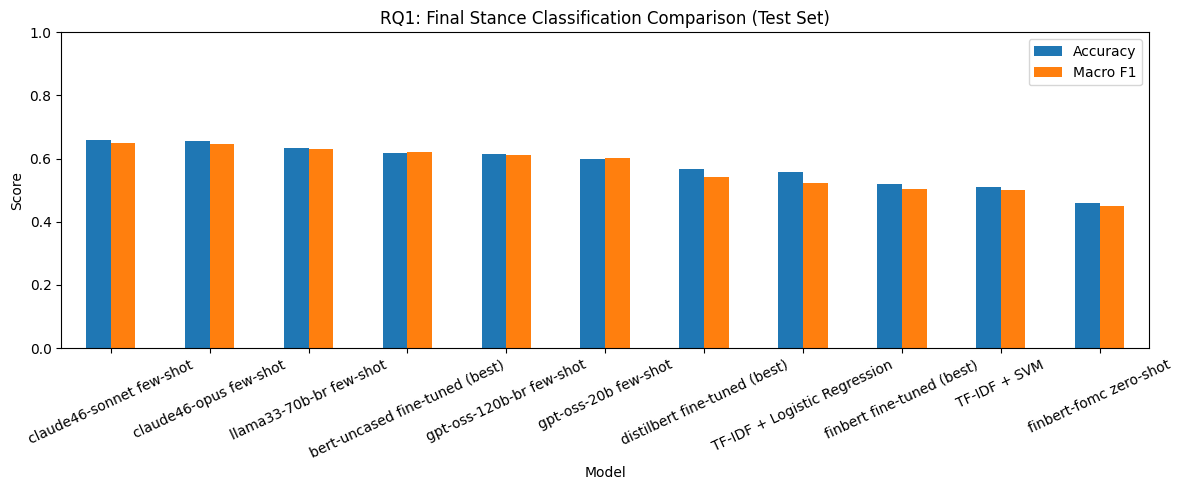

In [118]:
# ── RQ1 Final Table ───────────────────────────────────────────────────────────
_mf1 = lambda yt, yp: f1_score(yt, yp, average='macro', zero_division=0)
_acc = lambda yt, yp: accuracy_score(yt, yp)

rq1_rows = []

# TF-IDF + LR
_, lo, hi = bootstrap_ci(test_df['label'].values, y_pred_tfidf, _mf1)
rq1_rows.append(('TF-IDF + Logistic Regression',
                 accuracy_score(test_df['label'], y_pred_tfidf), tfidf_macro_f1, lo, hi))

# TF-IDF + SVM
_, lo, hi = bootstrap_ci(test_df['label'].values, y_pred_svm, _mf1)
rq1_rows.append(('TF-IDF + SVM',
                 accuracy_score(test_df['label'], y_pred_svm), svm_macro_f1, lo, hi))

if 'bert_results' not in globals():
    bert_results = {}
for _cfg in BERT_MODELS:
    _sl = _cfg['slug']
    if _sl not in bert_results or (
            _cfg['type'] == 'finetune' and not isinstance(bert_results.get(_sl), pd.DataFrame)):
        if _cfg['type'] == 'finetune' and os.path.exists(_cfg['checkpoint']):
            bert_results[_sl] = pd.read_csv(_cfg['checkpoint'])
        elif _cfg['type'] != 'finetune' and os.path.exists(_cfg.get('preds', '')):
            bert_results[_sl] = np.load(_cfg['preds'])

# BERT-family models — driven by BERT_MODELS config
for model_cfg in BERT_MODELS:
    slug = model_cfg['slug']
    _bt  = np.array(test_df['label'])
    if model_cfg['type'] == 'finetune':
        preds_path = model_cfg['preds']
        if not os.path.exists(preds_path):
            continue
        _bp = np.load(preds_path)
        _, lo, hi = bootstrap_ci(_bt, _bp, _mf1)
        rq1_rows.append((f'{slug} fine-tuned (best)',
                         accuracy_score(_bt, _bp), f1_score(_bt, _bp, average='macro'), lo, hi))
    else:  # zero-shot
        _preds = bert_results.get(slug, np.array([]))
        if len(_preds) == 0:
            continue
        _, lo, hi = bootstrap_ci(_bt, _preds, _mf1)
        rq1_rows.append((f'{slug} zero-shot',
                         accuracy_score(_bt, _preds), f1_score(_bt, _preds, average='macro'), lo, hi))

# LLM models — no bootstrap CI (predictions aggregated from checkpoint, not raw per-run)
for slug, rpt in llm_results.items():
    slug_acc = rpt.loc['accuracy',  'f1-score']
    slug_mf1 = rpt.loc['macro avg', 'f1-score']
    rq1_rows.append((f'{slug} few-shot', slug_acc, slug_mf1, float('nan'), float('nan')))

rq1_final = pd.DataFrame(rq1_rows, columns=['Model', 'Accuracy', 'Macro F1', 'CI lo', 'CI hi'])
rq1_final = rq1_final.sort_values('Macro F1', ascending=False).reset_index(drop=True)
print('RQ1 — Stance Classification (test n=194, 95% bootstrap CI on macro-F1)\n')
for _, r in rq1_final.iterrows():
    ci_str = f'[{r["CI lo"]:.4f}, {r["CI hi"]:.4f}]' if not np.isnan(r['CI lo']) else 'n/a'
    print(f'  {r["Model"]:<38}  acc={r["Accuracy"]:.4f}  mF1={r["Macro F1"]:.4f}  95% CI={ci_str}')

ax = rq1_final.set_index('Model')[['Accuracy', 'Macro F1']].plot(kind='bar', figsize=(12, 5), rot=25)
ax.set_ylim(0, 1); ax.set_title('RQ1: Final Stance Classification Comparison (Test Set)')
ax.set_ylabel('Score'); plt.tight_layout(); plt.show()


RQ2 — Market Direction (3-day, temporal test, 95% CI)

  Majority class                                 acc=0.6667  95% CI=[0.4815, 0.8148]
  Macro + Generic Sentiment                      acc=0.6296  95% CI=[0.2963, 0.6667]
  Macro + Sent + Growth Stance                   acc=0.6296  95% CI=[0.2963, 0.6667]
  Sent + Growth Stance only                      acc=0.6296  95% CI=[0.4815, 0.8148]
  RF (Macro+Sent+LLM Stance)                     acc=0.6296  95% CI=[0.4444, 0.8148]
  Macro only                                     acc=0.5926  95% CI=[0.2963, 0.6667]
  Macro + Growth Stance                          acc=0.5926  95% CI=[0.2963, 0.6667]
  Macro + LLM Stance                             acc=0.5926  95% CI=[0.2963, 0.6667]
  Macro + Sent + LLM Stance                      acc=0.5926  95% CI=[0.2963, 0.6667]
  Macro + Sent + All Stance                      acc=0.5926  95% CI=[0.2963, 0.6667]
  RF (Macro+Sent+Growth Stance)                  acc=0.5926  95% CI=[0.4074, 0.7778]

  Majorit

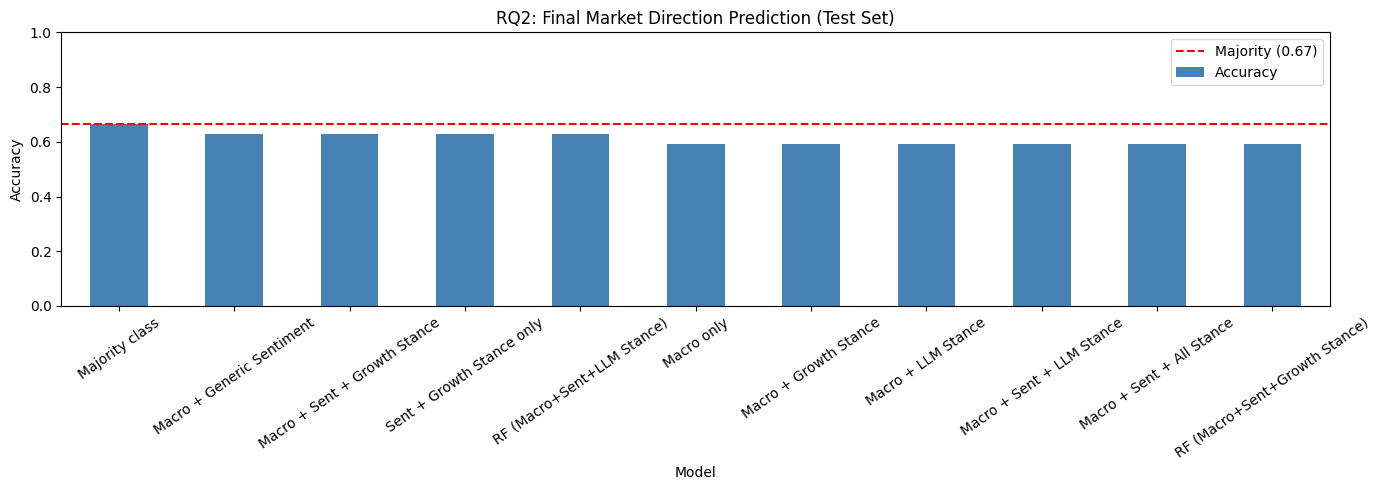

Saved rq2_results_final_with_ci.csv


In [119]:
# ── RQ2 Final Table with bootstrap CIs ───────────────────────────────────────
rq2_ci_rows = []

for name, feats in feature_specs:
    if feats is None:
        _maj = int(y_train_ev.mean() >= 0.5)
        _yp  = np.full(len(y_test_ev), _maj)
    else:
        _, pipe = _lr_pipe(train_ev[feats].fillna(0).values,
                           test_ev[feats].fillna(0).values,
                           y_train_ev, y_test_ev)
        _yp = pipe.predict(test_ev[feats].fillna(0).values)
    acc = accuracy_score(y_test_ev, _yp)
    _, lo, hi = bootstrap_ci(y_test_ev, _yp, _acc)
    rq2_ci_rows.append((name, acc, lo, hi))

_, lo, hi = bootstrap_ci(y_test_ev, rf_preds, _acc)
rq2_ci_rows.append(('RF (Macro+Sent+Growth Stance)', rf_acc, lo, hi))

if rf_llm_preds is not None:
    _, lo, hi = bootstrap_ci(y_test_ev, rf_llm_preds, _acc)
    rq2_ci_rows.append(('RF (Macro+Sent+LLM Stance)', rf_llm_acc, lo, hi))

rq2_final = pd.DataFrame(rq2_ci_rows, columns=['Model','Accuracy','CI lo','CI hi'])
rq2_final = rq2_final.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('RQ2 — Market Direction (3-day, temporal test, 95% CI)\n')
for _, r in rq2_final.iterrows():
    print(f'  {r["Model"]:<45}  acc={r["Accuracy"]:.4f}  '
          f'95% CI=[{r["CI lo"]:.4f}, {r["CI hi"]:.4f}]')
print(f'\n  Majority baseline: {majority_ev:.4f}')

ax = rq2_final.set_index('Model')['Accuracy'].plot(
    kind='bar', figsize=(14, 5), rot=35, color='steelblue')
ax.axhline(majority_ev, color='red', linestyle='--', label=f'Majority ({majority_ev:.2f})')
ax.set_ylim(0, 1); ax.set_ylabel('Accuracy'); ax.legend()
ax.set_title('RQ2: Final Market Direction Prediction (Test Set)')
plt.tight_layout(); plt.show()

rq2_final.to_csv('./data/processed/rq2_results_final_with_ci.csv', index=False)
print('Saved data/processed/rq2_results_final_with_ci.csv')